<h1 style="text-align: center">Brain Tumor Image Segmentation with U-Net</h1>

## 1. Dataset Overview

### 1.1 Download Dataset

Download the dataset from offical website by following the instructions:

* Visit http://medicaldecathlon.com
* Under the Data section, select Direct from AWS
* Choose `Task01_BrainTumour`

Or download by running the following scripts:

In [28]:
import os


if not os.path.exists('Task01_BrainTumour.tar'):
    print("Dataset not found locally, downloading now...")
    !wget -q https://msd-for-monai.s3-us-west-2.amazonaws.com/Task01_BrainTumour.tar -O Task01_BrainTumour.tar # silently downloads a .tar archive containing the Brain Tumour dataset.
    print("Download complete!")
else:
    print("Dataset archive already exists, skipping download.")

Dataset not found locally, downloading now...
^C
Download complete!


Extract the dataset:

In [ ]:
if not os.path.exists('Task01_BrainTumour'):
    print("Extracting the dataset...")
    !tar -xf Task01_BrainTumour.tar
    print("Extraction complete!")
else:
    print("Dataset folder already exists, skipping extraction.")

print("Verifying the contents of the Task01_BrainTumour directory:")
!ls Task01_BrainTumour

Dataset folder already exists, skipping extraction.
Verifying the contents of the Task01_BrainTumour directory:
dataset.json  imagesTr	imagesTs  labelsTr


Clean up:

In [ ]:
!rm Task01_BrainTumour.tar
print("Cleaned up the tar file after extraction!")

Cleaned up the tar file after extraction!


The downloaded file structure should look like this:

* `imagesTr` and `labelsTr`: Training images and segmentation labels.
* `imagesTs` and `labelsTs`: Testing images and segmentation labels.
* Each subject has multiple `.nii.gz` files representing different MRI modalities, plus one segmentation mask.

Visualize the file structure:

In [ ]:
!tree Task01_BrainTumour -L 2

/bin/bash: line 1: tree: command not found


### 1.2 Explore Different MRI Modalities

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import glob

In [ ]:
image_dir = 'Task01_BrainTumour/imagesTr'
label_dir = 'Task01_BrainTumour/labelsTr'

image_paths = sorted(glob.glob(os.path.join(image_dir, '*.nii.gz')))
label_paths = sorted(glob.glob(os.path.join(label_dir, '*.nii.gz')))

In [ ]:
def load_nifti(path: str) -> np.ndarray:
    nifti_obj = nib.load(path)
    return nifti_obj.get_fdata()

In [ ]:
def display_image_label(image_paths, label_paths, num_examples, channel_idx):    
    fig, axes = plt.subplots(num_examples, 3, figsize=(18, 12))
    
    if num_examples == 1:
        axes = [axes]
    
    print(f"Visualization for the channel {channel_idx+1}:")
    
    for i in range(num_examples):
        image_path = image_paths[1]
        label_path = label_paths[1]
        
        image = load_nifti(image_path) # Shape: (H, W, D) or (H, W, D, C) if multiple channels. D is # of slices
        label = load_nifti(label_path) # shape: (H, W, D)

        if image.ndim == 4:
            slice_idx = image.shape[2] // 2  # Pick a middle slice
            img_slice = image[:, :, slice_idx, channel_idx]
            lbl_slice = label[:, :, slice_idx]
            
        else:
            # If there's only one channel, the shape should be (H, W, D)
            slice_idx = image.shape[2] // 2
            img_slice = image[:, :, slice_idx]
            lbl_slice = label[:, :, slice_idx]
        
        # Display the image slice
        axes[i][0].imshow(img_slice, cmap='gray')
        axes[i][0].set_title(f'Example {i+1}: Image Slice')
        axes[i][0].axis('off')

        # Display the label slice
        axes[i][1].imshow(lbl_slice, cmap='gray')
        axes[i][1].set_title('Label Slice')
        axes[i][1].axis('off')

        # Display an overlay of label on the image
        axes[i][2].imshow(img_slice, cmap='gray')
        axes[i][2].imshow(lbl_slice, cmap='jet', alpha=0.5)
        axes[i][2].set_title('Image + Label Overlay')
        axes[i][2].axis('off')
        
    plt.tight_layout()
    plt.show()

**Fluid-Attenuated Inversion Recovery（FLAIR)**

Visualization for the channel 1:


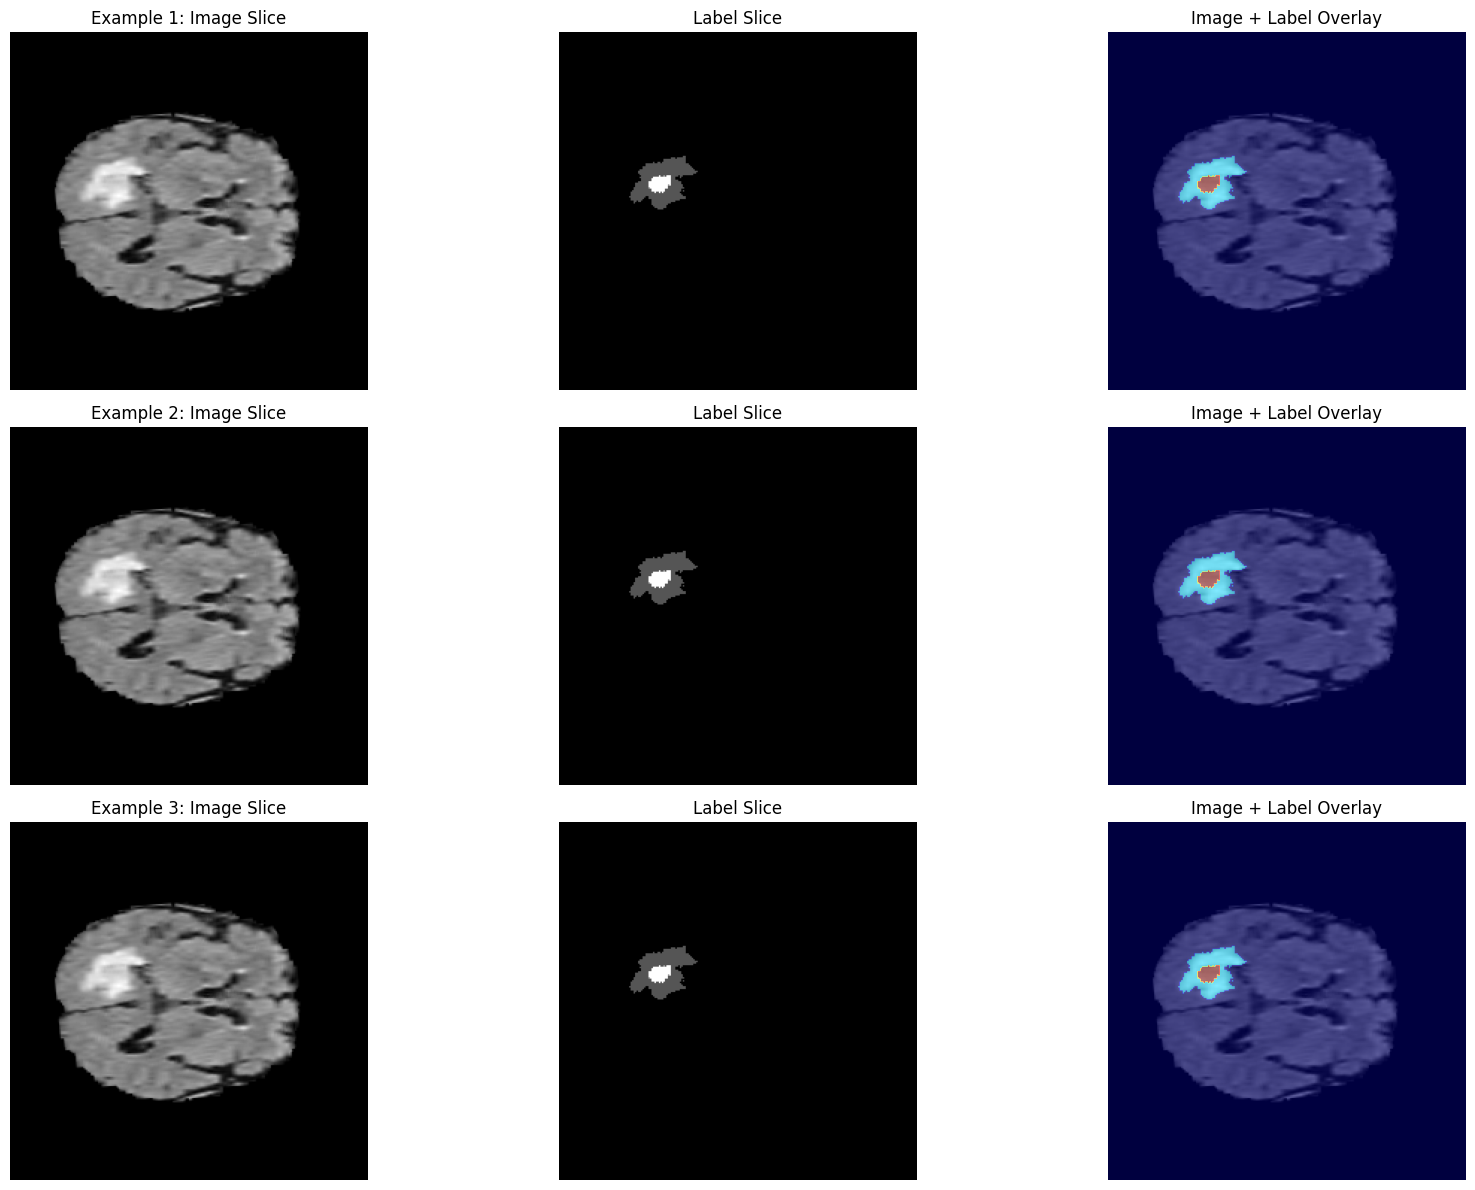

In [ ]:
num_examples = 3
channel_idx = 0

display_image_label(image_paths, label_paths, num_examples, channel_idx)

**T1-weighted**

Visualization for the channel 2:


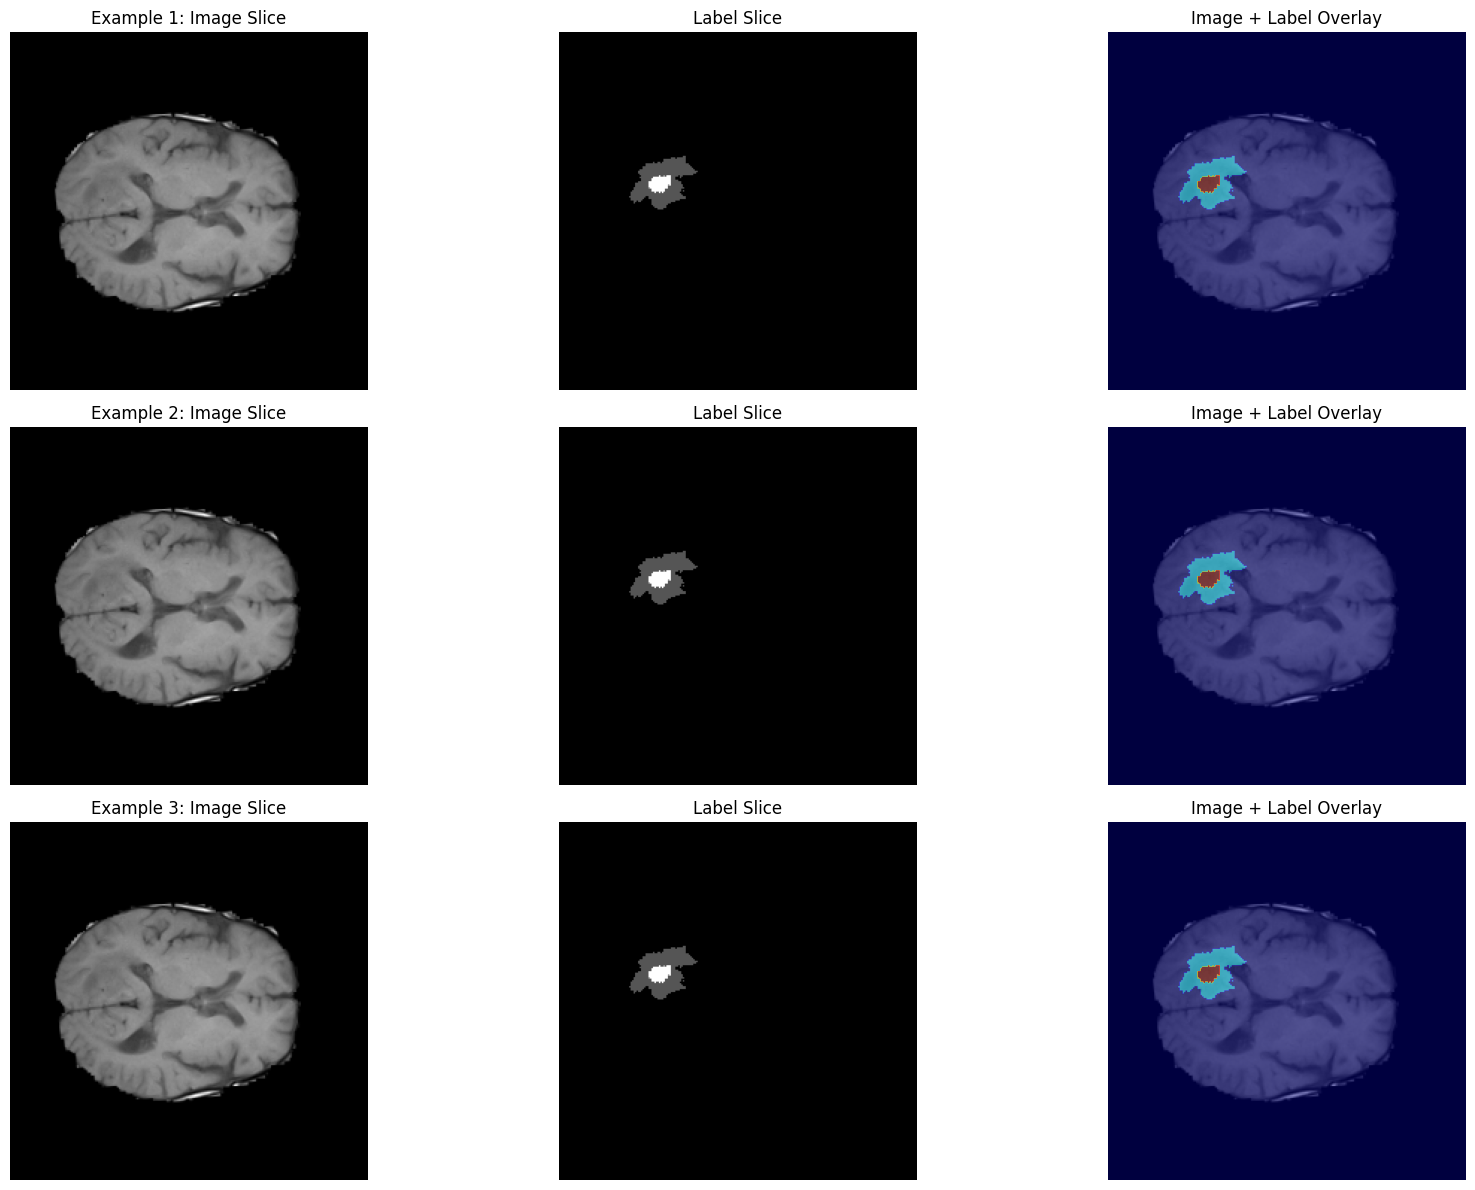

In [ ]:
channel_idx = 1
display_image_label(image_paths, label_paths, num_examples, channel_idx)

**T1-weighted with Contrast Enhancement**

Visualization for the channel 3:


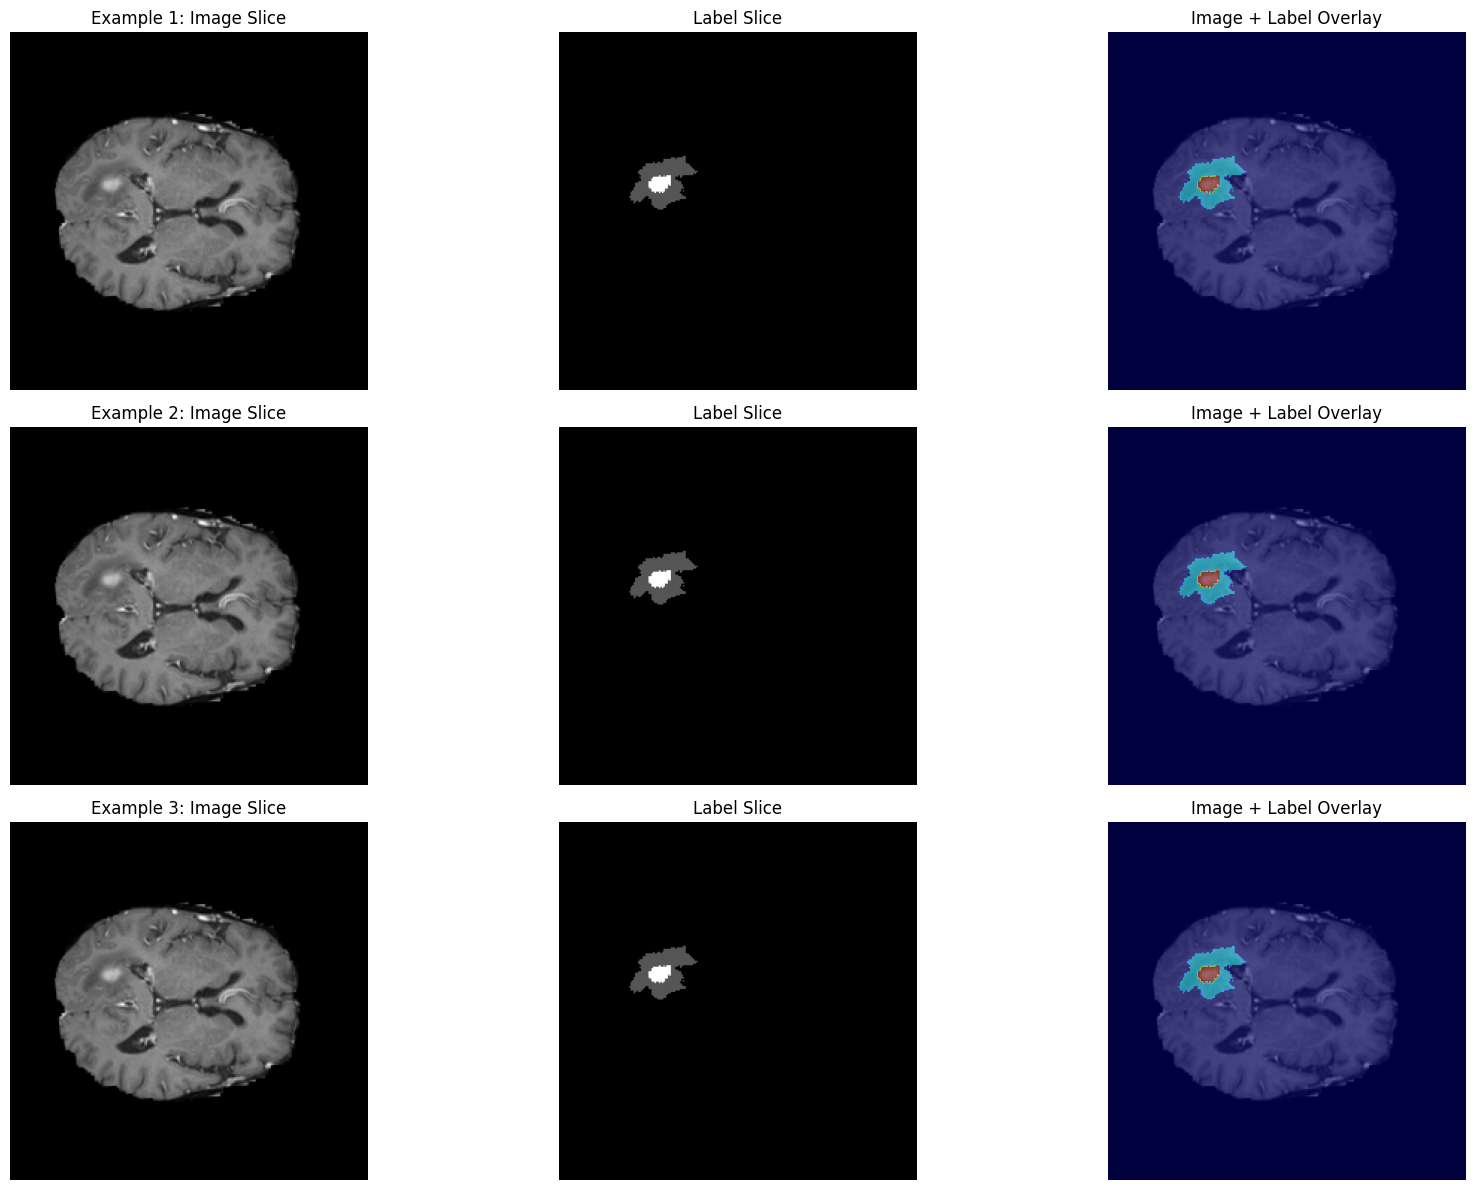

In [ ]:
channel_idx = 2
display_image_label(image_paths, label_paths, num_examples, channel_idx)

**T2-weighted**

Visualization for the channel 4:


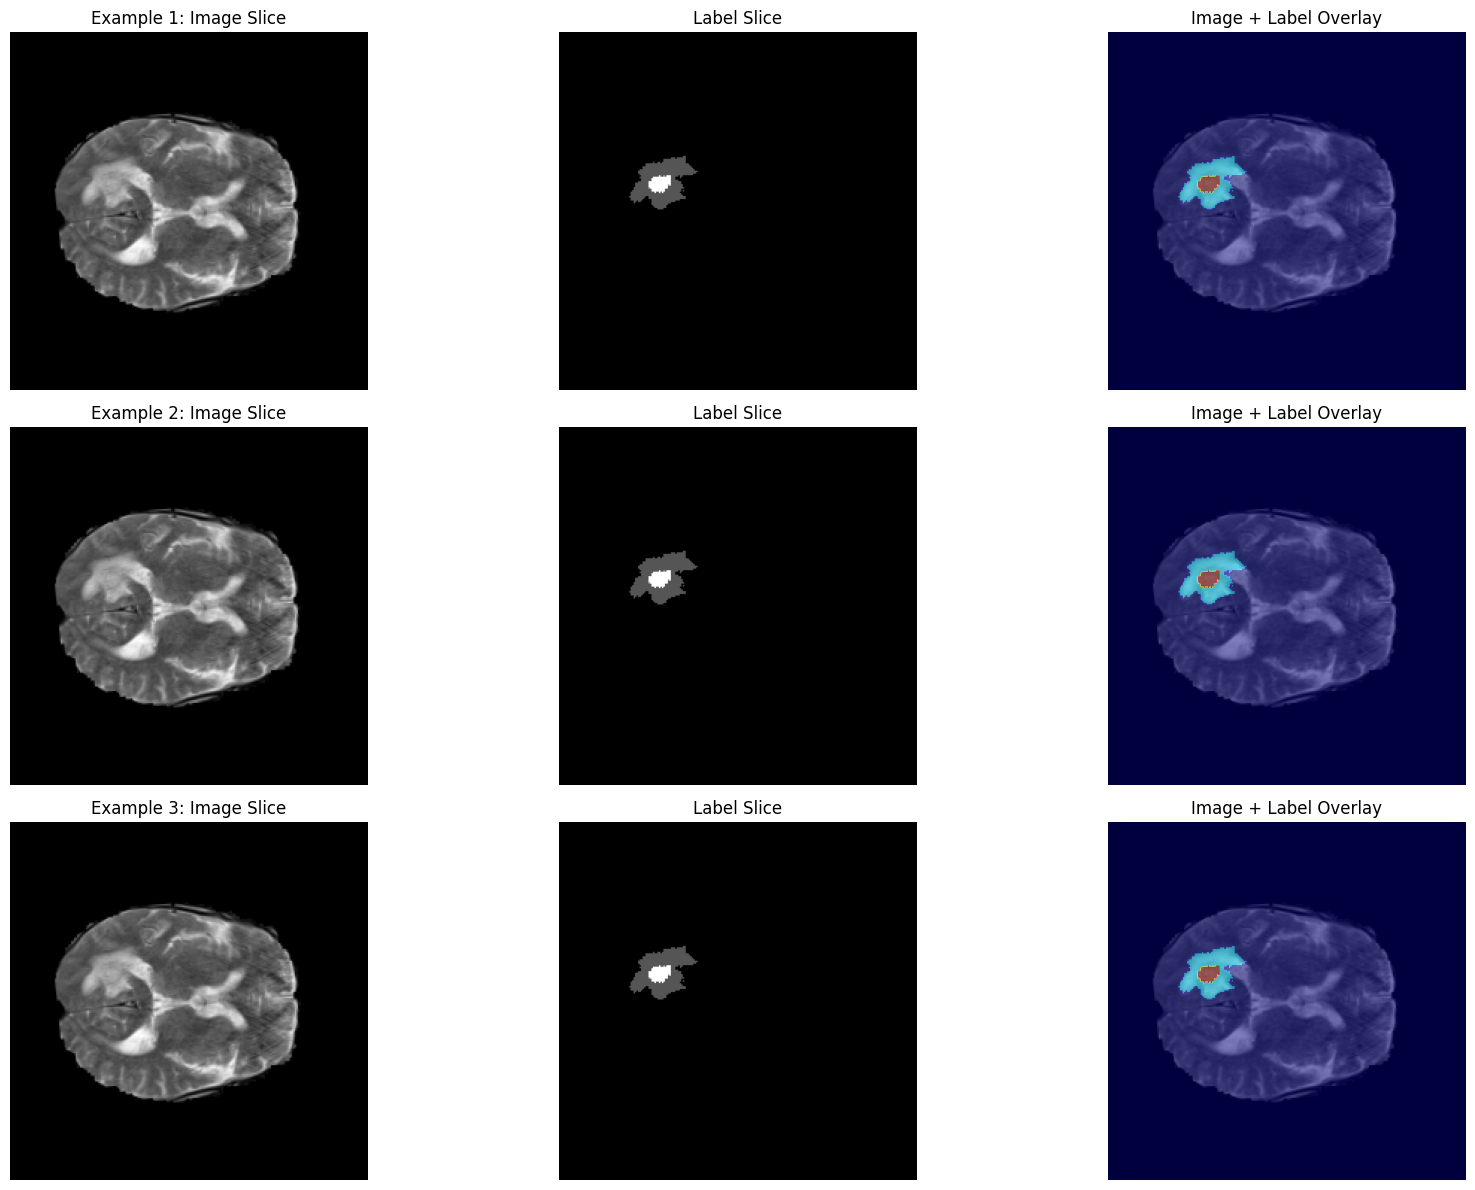

In [ ]:
channel_idx = 3
display_image_label(image_paths, label_paths, num_examples, channel_idx)

## 2. Load Dataset

In [ ]:
import torch
import random
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from graphviz import Digraph

### 2.1 Utility functions

#### 2.1.1 Normailization

$$
x_{\text{norm}} = \frac{x - \mu}{\sigma}
$$

In [ ]:
def normalize(volume):
    mean = np.mean(volume)
    std = np.std(volume)
    return (volume - mean) / (std + 1e-8)

#### 2.1.2 Resize

Resize the images to target size with the help of `scipy.ndimage.zoom`, which is a function used for zooming (scaling) multi-dimensional images.

Interpolation Order:
* `order=0`: Nearest-neighbor interpolation
* `order=1`: Linear interpolation

In [ ]:
from scipy.ndimage import zoom

def resize(image, target_shape, is_seg=False):
    current_shape = image.shape
    zoom_factors = [t / c for t, c in zip(target_shape, current_shape)]
    if is_seg:
        return zoom(image, zoom_factors, order=0)
    else:
        return zoom(image, zoom_factors, order=1)

#### 2.1.3 Some other data augmentation methods

In [ ]:
# Random flip

def random_flip(image, seg):
    if random.random() < 0.5:
        image = np.flip(image, axis=1)
        seg = np.flip(seg, axis=1)
    if random.random() < 0.5:
        image = np.flip(image, axis=0)
        seg = np.flip(seg, axis=0)
    return image, seg

In [ ]:
# Random rotation

from scipy.ndimage import rotate

def random_rotate(image, seg, max_angle=5):
    angle = random.uniform(-max_angle, max_angle)
    image_rot = rotate(image, angle, axes=(0,1), reshape=False, order=1)
    seg_rot = rotate(seg, angle, axes=(0,1), reshape=False, order=0)
    return image_rot, seg_rot

In [ ]:
# Intensity jitter

def intensity_jitter(image, brightness_factor=0.1, contrast_factor=0.1):
    # Random brightness shift
    delta = (random.random() * 2 - 1) * brightness_factor * np.mean(image)
    image = image + delta

    # Random contrast shift
    alpha = 1.0 + (random.random() * 2 - 1) * contrast_factor
    mean_val = np.mean(image)
    image = (image - mean_val) * alpha + mean_val
    return image

### 2.2 Define Custom Dataset

In [ ]:
class MedicalSegmentationDataset(Dataset):
    def __init__(self,
             image_paths,
             mask_paths,
             slice_choice='middle',
             target_shape=None,
             apply_augmentation=True):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.slice_choice = slice_choice
        self.target_shape = target_shape
        self.apply_augmentation = apply_augmentation
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # 1. Load Data
        image = load_nifti(self.image_paths[idx])
        mask = load_nifti(self.mask_paths[idx])
        
        # 2. Choose Slice (either middle or random)
        depth = image.shape[-1] if image.ndim == 3 else image.shape[-2]
        if self.slice_choice == 'middle':
            slice_idx = depth // 2
        elif self.slice_choice == 'random':
            slice_idx = random.randint(0, depth - 1)
        else:
            raise ValueError("slice_choice must be 'middle' or 'random'.")
            
        # Handle slicing logic for both multi-channel (4D) and single-channel (3D)
        if image.ndim == 4:
            image_slice = image[:, :, slice_idx, :]
        else:
            image_slice = image[:, :, slice_idx]
            
        mask_slice = mask[:, :, slice_idx]
        
        # 3. Normalize Image Slice
        # Don't normalize the mask because labels are discrete
        if image_slice.ndim == 3:
            # For multi-channel, normalize each channel separately
            for c in range(image_slice.shape[-1]):
                image_slice[..., c] = normalize(image_slice[..., c])
        else:
            image_slice = normalize(image_slice)
                
        # 4. Resize
        if self.target_shape is not None:
            if image_slice.ndim == 3:
                # Multi-channel image -> resize each channel
                _, _, c = image_slice.shape
                resized_channels = []
                for ch in range(c):
                    resized_ch = resize(image_slice[..., ch], self.target_shape, is_seg=False)
                    resized_channels.append(resized_ch)
                # Stack back along channel dim
                image_slice = np.stack(resized_channels, axis=-1)
                # Resize mask
                mask_slice = resize(mask_slice, self.target_shape, is_seg=True) 
            else:
                image_slice = resize(image_slice, self.target_shape, is_seg=False)
                mask_slice = resize(mask_slice, self.target_shape, is_seg=True)
                
        # 5. Augmentation
        if self.apply_augmentation:
            # If multi-channel, apply augmentations on each channel identically
            if image_slice.ndim == 3:  # shape: (H, W, C)
                # random_flip and random_rotate operate on (H, W) arrays
                # -> stack channels along the 3rd axis, apply once
                # -> we treat channels as if they're a "stack"
                image_slice, mask_slice = random_flip(image_slice, mask_slice)
                image_slice, mask_slice = random_rotate(image_slice, mask_slice, max_angle=5)
                # For intensity jitter, apply it in each channel separately
                for c in range(image_slice.shape[-1]):
                    image_slice[..., c] = intensity_jitter(image_slice[..., c])
            else:
                image_slice, mask_slice = random_flip(image_slice, mask_slice)
                image_slice, mask_slice = random_rotate(image_slice, mask_slice, max_angle=5)
                image_slice = intensity_jitter(image_slice)
                
        # 6. Convert to Torch Tensor
        if image_slice.ndim == 3:
            # multi-channel: shape -> (C, H, W)
            image_slice = np.transpose(image_slice, (2, 0, 1))
            mask_slice = np.expand_dims(mask_slice, axis=0)
        else:
            # single-channel: shape -> (1, H, W)
            image_slice = np.expand_dims(image_slice, axis=0)
            mask_slice = np.expand_dims(mask_slice, axis=0)

        image_slice = torch.from_numpy(image_slice).float()
        mask_slice = torch.from_numpy(mask_slice).long()

        return image_slice, mask_slice

### 2.3 Load

In [ ]:
if __name__ == "__main__":

    image_dir = "Task01_BrainTumour/imagesTr"
    mask_dir = "Task01_BrainTumour/labelsTr"
    image_paths = sorted(glob.glob(os.path.join(image_dir, "*.nii.gz")))
    mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.nii.gz")))

    dataset = MedicalSegmentationDataset(
        image_paths=image_paths,
        mask_paths=mask_paths,
        slice_choice='middle',   
        target_shape=(256, 256),  
        apply_augmentation=True
    )

    dataloader = DataLoader(
        dataset,
        batch_size=20,
        shuffle=True,
        pin_memory=True
    )

Check the shapes of both the training data (`images.shape`) and the label (`masks.shape`).

In [ ]:
for batch_idx, (images, masks) in enumerate(dataloader):
    print(f"Batch {batch_idx} - Images shape: {images.shape}, Masks shape: {masks.shape}")
    break

Batch 0 - Images shape: torch.Size([20, 4, 256, 256]), Masks shape: torch.Size([20, 1, 256, 256])


## 3. Model

### 3.1 Model Architecture

The UNet consists of a **Down-sampling path** (Encoder) and an **Up-sampling path** (Decoder). 

The **down-sampling path** reduces the spatiali dimensions of images and extracts features. In this implementation for down-sampling, we applies two consecutive 3×3 convolution operations following by a ReLU activation and adds a 2x2 max pooling operation with stride of 2 for downsampling.

A **bottle neck** is applied between down-sampling path and up-sampling path to compress high-level features. The structure is also two consecutive 3×3 convolutions, each followed by a ReLu activation.

The **up-sampling path** introduces 2×2 **Transposed Convolution** for upsampling. Also applies skip connections to concatenate upsampled features with corresponding encoder features. Then we applied two consecutive 3×3 convolutions, each followed by a ReLu activation.

For details, please refer to [original paper](https://arxiv.org/abs/1505.04597).

### 3.2 Helper Modules

In [ ]:
from torch import nn

class DoubleConv(nn.Module):
    """
    A helper module that performs two consecutive convolutional layers, each followed by a ReLU. 
    Optionally applies normalization (BatchNorm/InstanceNorm/GroupNorm) and dropout.
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        norm_type: str,
        dropout: float
    ):
        super().__init__()
        layers = []

        # First Conv
        layers.append(nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1, bias=True))
        if norm_type=='batch':
            layers.append(nn.BatchNorm2d(out_channels))
        if norm_type=='instance':
            layers.append(nn.InstanceNorm2d(out_channels))
        if norm_type=='group':
            layers.append(nn.GroupNorm(num_groups=8, num_channels=out_channels))
        layers.append(nn.ReLU())

        # Second Conv
        layers.append(nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1, bias=True))
        if norm_type == 'batch':
            layers.append(nn.BatchNorm2d(out_channels))
        elif norm_type == 'instance':
            layers.append(nn.InstanceNorm2d(out_channels, affine=True))
        elif norm_type == 'group':
            layers.append(nn.GroupNorm(num_groups=8, num_channels=out_channels))
        layers.append(nn.ReLU(inplace=True))

        # Optional dropout
        if dropout > 0.0:
            layers.append(nn.Dropout(p=dropout))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)
        

### 3.3 Build the Model

In [ ]:
class UNet(nn.Module):
    def __init__(
        self, 
        in_channels: int = 1,
        out_channels: int = 2,
        base_filters: int = 64,
        norm_type: str = None,
        dropout: float = .0
    ):
        super().__init__()

        # Downsampling Layer
        self.down1 = DoubleConv(in_channels=in_channels, out_channels=base_filters, norm_type=norm_type, dropout=dropout)
        self.down2 = DoubleConv(in_channels=base_filters, out_channels=base_filters*2, norm_type=norm_type, dropout=dropout)
        self.down3 = DoubleConv(in_channels=base_filters*2, out_channels=base_filters*4, norm_type=norm_type, dropout=dropout)
        self.down4 = DoubleConv(in_channels=base_filters*4, out_channels=base_filters*8, norm_type=norm_type, dropout=dropout)

        # MaxPool
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # BottleNeck
        self.bottleneck = DoubleConv(in_channels=base_filters*8, out_channels=base_filters*16, norm_type=norm_type, dropout=dropout)

        # Upsampling Layer
        self.up_trans1 = nn.ConvTranspose2d(base_filters * 16, base_filters * 8, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(base_filters*16, base_filters*8, norm_type=norm_type, dropout=dropout)

        self.up_trans2 = nn.ConvTranspose2d(base_filters * 8, base_filters * 4, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(base_filters * 8, base_filters * 4, norm_type=norm_type, dropout=dropout)

        self.up_trans3 = nn.ConvTranspose2d(base_filters * 4, base_filters * 2, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(base_filters * 4, base_filters * 2, norm_type=norm_type, dropout=dropout)

        self.up_trans4 = nn.ConvTranspose2d(base_filters * 2, base_filters, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(base_filters * 2, base_filters, norm_type=norm_type, dropout=dropout)

        self.out_conv = nn.Conv2d(base_filters, out_channels, kernel_size=1)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Downsampleing
        d1 = self.down1(x) # (N, 64, H, W)
        p1 = self.pool(d1) # (N, 64, H/2, W/2)

        d2 = self.down2(p1)       # (N, 128, H/2, W/2)
        p2 = self.pool(d2)        # (N, 128, H/4, W/4)

        d3 = self.down3(p2)       # (N, 256, H/4, W/4)
        p3 = self.pool(d3)        # (N, 256, H/8, W/8)

        d4 = self.down4(p3)       # (N, 512, H/8, W/8)
        p4 = self.pool(d4)        # (N, 512, H/16, W/16)

        # Bottleneck
        bn = self.bottleneck(p4)  # (N, 1024, H/16, W/16)

        # Upsampling
        up1 = self.up_trans1(bn)              # (N, 512, H/8, W/8)
        cat1 = torch.cat([up1, d4], dim=1)    # (N, 512+512, H/8, W/8)
        u1 = self.up_conv1(cat1)              # (N, 512, H/8, W/8)

        up2 = self.up_trans2(u1)              # (N, 256, H/4, W/4)
        cat2 = torch.cat([up2, d3], dim=1)    # (N, 256+256, H/4, W/4)
        u2 = self.up_conv2(cat2)              # (N, 256, H/4, W/4)

        up3 = self.up_trans3(u2)              # (N, 128, H/2, W/2)
        cat3 = torch.cat([up3, d2], dim=1)    # (N, 128+128, H/2, W/2)
        u3 = self.up_conv3(cat3)              # (N, 128, H/2, W/2)

        up4 = self.up_trans4(u3)              # (N, 64, H, W)
        cat4 = torch.cat([up4, d1], dim=1)    # (N, 64+64, H, W)
        u4 = self.up_conv4(cat4)              # (N, 64, H, W)

        out = self.out_conv(u4)               # (N, out_channels, H, W)

        return out

## 4. Train

### 4.1 Loss Function and Evaluation Metrics

The Loss Function used for this task is **Cross-Entropy Loss**. Here's an introduction:

Cross-entropy loss is used to evaluate how well the predicted probability distribution $\hat{y}$  matches the ground-truth distribution $y$.  Here's a mathematical definition of the cross entropy loss when the label is one-hot encoded:
   
$$
L_{\text{CE}} = -\frac{1}{N} \sum_{i=1}^N \sum_{c=1}^C y_{i, c} \log \bigl(\hat{p}_{i, c}\bigr)
$$  
   
Here,
* $N$ is the number of samples,
* $C$ is the number of classes,
* $y_{i,c}$ is 1 if the $i$-th sample belongs to class $c$ and 0 otherwise,
* $\hat{p}_{i,c}$ is the predicted probability of the $i$-th sample for class $c$.
   
If the model assigns a low probability to the correct class, the loss will be high, encouraging the model during training to adjust its parameters to assign higher probabilities to the correct classes.

In [ ]:
criterion = nn.CrossEntropyLoss()

Another metric that can be used as loss function for segmentation task is **Dice Coefficient**. Dice coefficient measures the overlap between two samples. It calculated by 2 * intersection divided by the total number of pixel in both images as shown below:

$$
\text{Dice}(A, B) = \frac{2 |A \cap B|}{|A| + |B|}
$$  
Where，
* $A$ is the set of predicted positive pixels/voxel
* $B$ is the set of ground-truth positive pixels/voxels. 
  
The Dice score ranges from 0 (no overlap) to 1 (perfect overlap). In this project, it will only be used as an evaluation metric.

In [ ]:
def dice_coefficient(pred, target, smooth=1e-6):
    # 1. Pick the class with the highest probability at each pixel
    pred_labels = torch.argmax(pred, dim=1)

    # 2. One-hot encode predicted and target
    num_classes = pred.shape[1]
    pred_one_hot = F.one_hot(pred_labels, num_classes=num_classes).permute(0, 3, 1, 2).float()
    target_one_hot = F.one_hot(target.long(), num_classes=num_classes).permute(0, 3, 1, 2).float()

    # 3. Compute Dice
    intersection = (pred_one_hot * target_one_hot).sum(dim=(2, 3))
    union = pred_one_hot.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))

    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)

    # average over classes & batch
    return dice_per_class.mean()
    

### 4.2 Define Training Function

In [ ]:
from tqdm import tqdm

def train(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=10,
    checkpoint_dir='checkpoints',
    checkpoint_freq=5
):
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_dice": [],
        "val_dice": []
    }

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        running_train_dice = 0.0

        # Train
        for images, masks in tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks.squeeze(1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            running_train_dice += dice_coefficient(outputs, masks.squeeze(1)).item()

        train_loss = running_train_loss / len(train_loader)
        train_dice = running_train_dice / len(train_loader)

        # Validate
        model.eval()
        running_val_loss = 0.0
        running_val_dice = 0.0
    
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Val Epoch {epoch+1}/{num_epochs}"):
                images = images.to(device)
                masks = masks.to(device)
    
                outputs = model(images)
                val_loss = criterion(outputs, masks.squeeze(1))
    
                running_val_loss += val_loss.item()
                running_val_dice += dice_coefficient(outputs, masks.squeeze(1)).item()
    
        val_loss = running_val_loss / len(val_loader)
        val_dice = running_val_dice / len(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)

        print(f"\nEpoch [{epoch+1}/{num_epochs}]"
              f" - Train Loss: {train_loss:.4f}, Train DSC: {train_dice:.4f}"
              f" | Val Loss: {val_loss:.4f}, Val DSC: {val_dice:.4f}")

        # Save checkpoint periodically
        if (epoch + 1) % checkpoint_freq == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f"unet_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Saved checkpoint: {checkpoint_path}")

    return history

### 4.3 Start Training

In [ ]:
from sklearn.model_selection import KFold

if __name__ == "__main__":

    image_dir = "Task01_BrainTumour/imagesTr"
    label_dir = "Task01_BrainTumour/labelsTr"

    all_image_paths = sorted(glob.glob(os.path.join(image_dir, "*.nii.gz")))
    all_label_paths = sorted(glob.glob(os.path.join(label_dir, "*.nii.gz")))

    print(f"Total images found: {len(all_image_paths)}")
    print(f"Total labels found: {len(all_label_paths)}")

    # Zip images & labels together so we keep matching image/label in the same index
    zipped_paths = list(zip(all_image_paths, all_label_paths))

    # Five fold cross validation
    num_splits = 5
    kfold = KFold(n_splits=num_splits, shuffle=True, random_state=42)

    fold_train_loss_history = []
    fold_val_loss_history   = []
    fold_train_dice_history = []
    fold_val_dice_history   = []

    # Set up the device
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    
    print(f"Device: {device}")

    # Define # of epochs, batch_size, etc.
    num_epochs = 30
    batch_size = 5
    learning_rate = 1e-4
    checkpoint_dir = 'checkpoints_brain_tumor'
    
    # Define a list for validation dataset
    val_datasets = [None for _ in range(5)] 

    # Train & validate for each fold
    for fold_idx, (train_indices, val_indices) in enumerate(kfold.split(zipped_paths)):
        print("\n"+"="*40)
        print(f"Starting Fold {fold_idx+1} / {num_splits}")
        print("="*40)

        train_subset = [zipped_paths[i] for i in train_indices]
        val_subset   = [zipped_paths[i] for i in val_indices]

        train_image_paths = [p[0] for p in train_subset]
        train_mask_paths  = [p[1] for p in train_subset]
        val_image_paths   = [p[0] for p in val_subset]
        val_mask_paths    = [p[1] for p in val_subset]

        train_dataset = MedicalSegmentationDataset(
            train_image_paths,
            train_mask_paths,
            target_shape=(128, 128),
            slice_choice='middle'
        )
        val_dataset = MedicalSegmentationDataset(
            val_image_paths,
            val_mask_paths,
            target_shape=(128, 128),
            slice_choice='middle'
        )
        
        val_datasets[fold_idx] = val_dataset

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
        val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

        model = UNet(in_channels=4, out_channels=4).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        
        fold_history = train(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            device=device,
            num_epochs=num_epochs,
            checkpoint_dir=os.path.join(checkpoint_dir, f"fold_{fold_idx+1}"),
            checkpoint_freq=5
        )

        fold_train_loss_history.append(fold_history["train_loss"])
        fold_val_loss_history.append(fold_history["val_loss"])
        fold_train_dice_history.append(fold_history["train_dice"])
        fold_val_dice_history.append(fold_history["val_dice"])


Total images found: 484
Total labels found: 484
Device: cuda

Starting Fold 1 / 5


Train Epoch 1/30:   5%|▌         | 4/78 [00:19<05:52,  4.77s/it]


KeyboardInterrupt: 

### 4.4 Visualization

Plot results per fold:

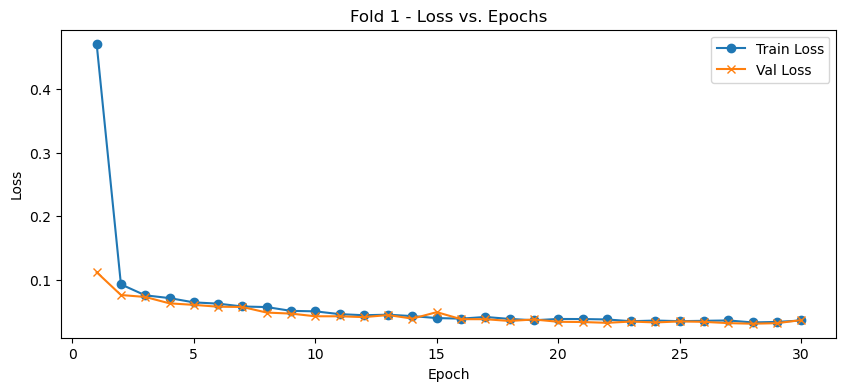

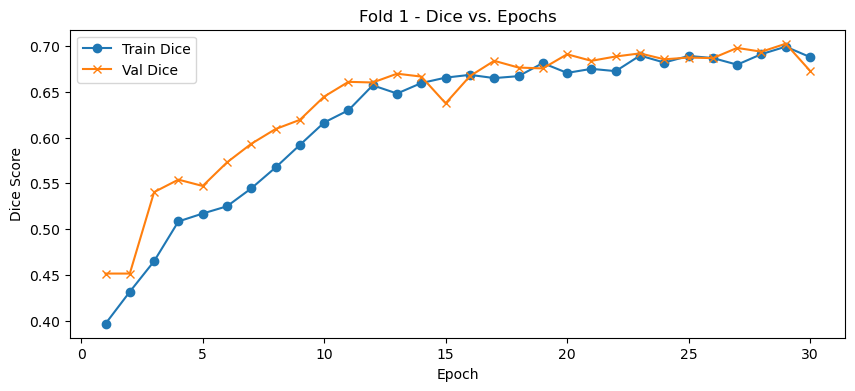

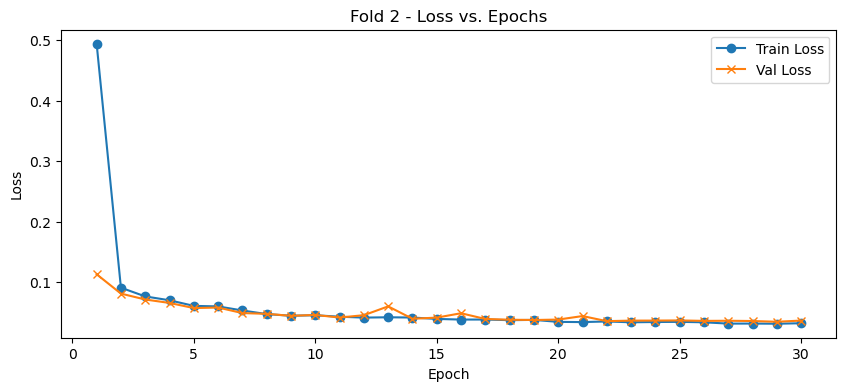

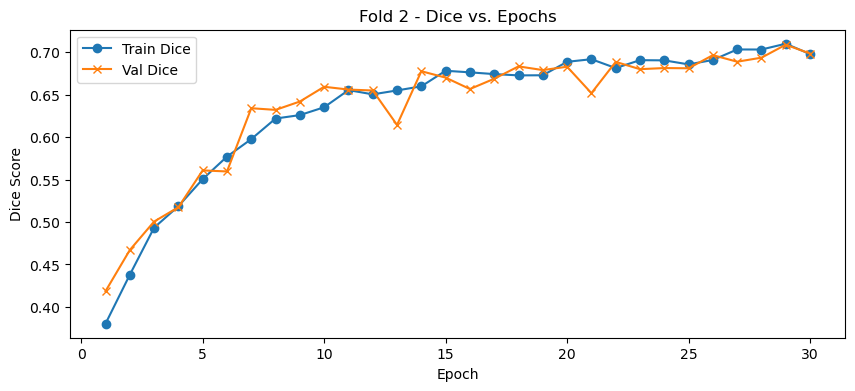

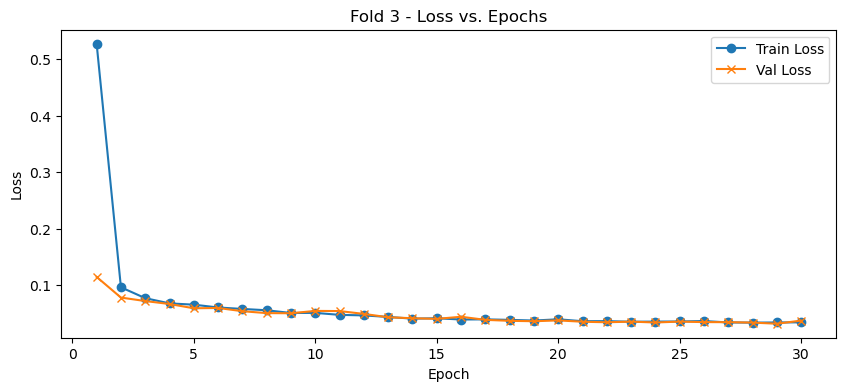

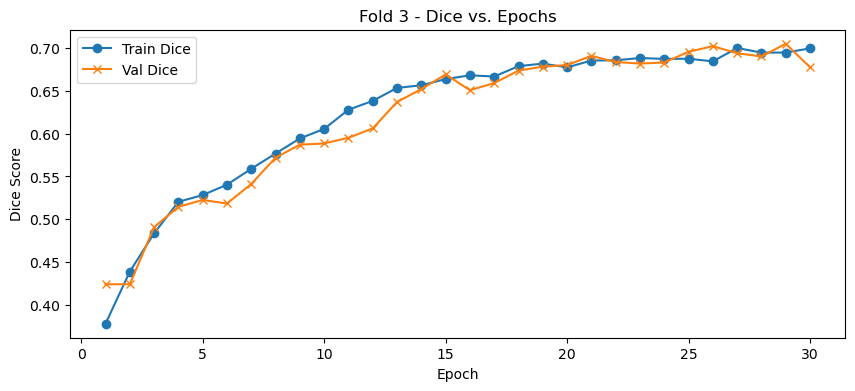

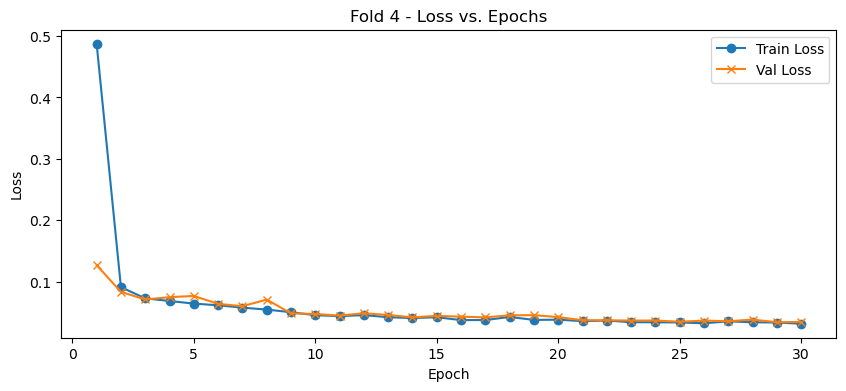

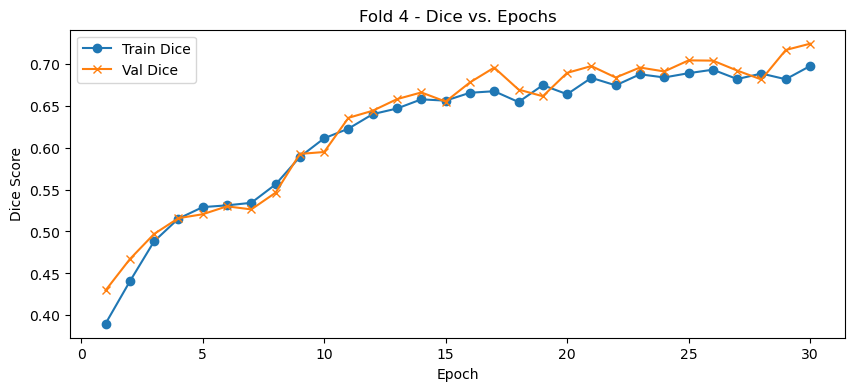

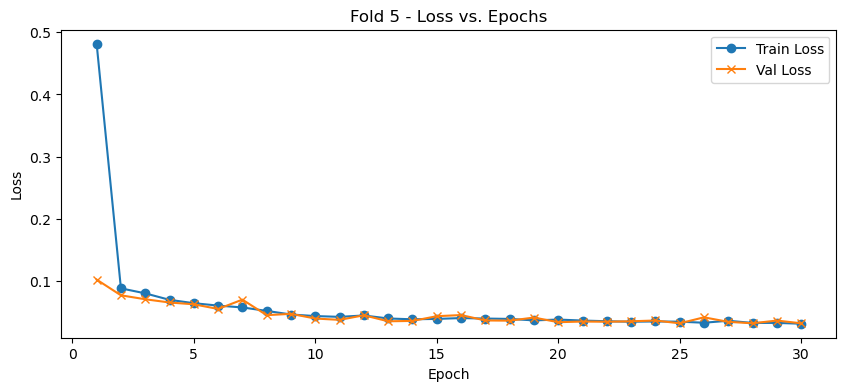

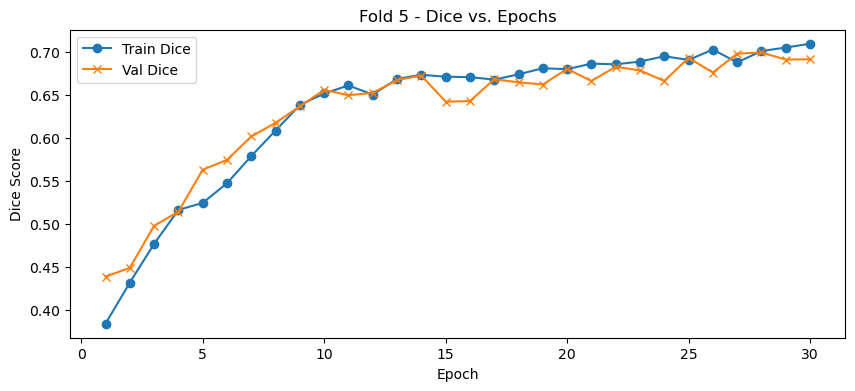

In [ ]:
if __name__ == "__main__":

    save_dir = "visualization/train"
    os.makedirs(save_dir, exist_ok=True)
    
    for fold_idx in range(num_splits):
        fold_train_loss = fold_train_loss_history[fold_idx]
        fold_val_loss   = fold_val_loss_history[fold_idx]
        fold_train_dice = fold_train_dice_history[fold_idx]
        fold_val_dice   = fold_val_dice_history[fold_idx]

        epochs_range = range(1, num_epochs + 1)

        # Plot Loss
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.set_title(f"Fold {fold_idx+1} - Loss vs. Epochs")
        ax.plot(epochs_range, fold_train_loss, label="Train Loss", marker='o')
        ax.plot(epochs_range, fold_val_loss, label="Val Loss", marker='x')
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        fig.tight_layout()

        loss_path = os.path.join(save_dir, f"fold{fold_idx+1}_loss.png")
        fig.savefig(loss_path, dpi=300)
        print(f"Saved training loss curve to {loss_path}")
        plt.show()
        plt.close(fig)

        # Plot DICE
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.set_title(f"Fold {fold_idx+1} - Dice vs. Epochs")
        ax.plot(epochs_range, fold_train_dice, label="Train Dice", marker='o')
        ax.plot(epochs_range, fold_val_dice, label="Val Dice", marker='x')
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Dice Score")
        ax.legend()
        fig.tight_layout()

        dice_path = os.path.join(save_dir, f"fold{fold_idx+1}_dice.png")
        fig.savefig(dice_path, dpi=300)
        print(f"Saved training dice curve to {dice_path}")
        plt.show()
        plt.close(fig)

Plot aggregate results across all folds:

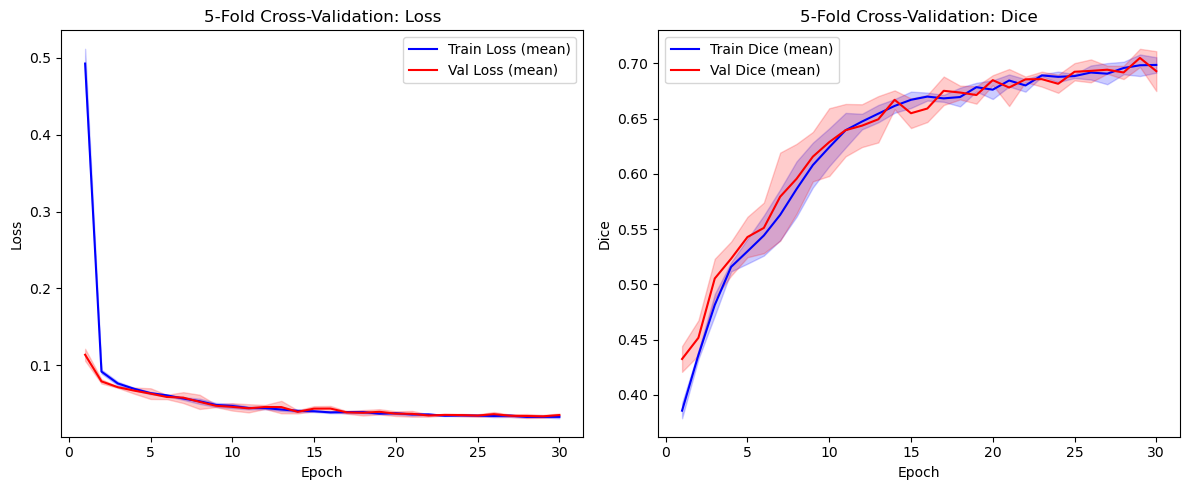

In [ ]:
if __name__ == "__main__":

    save_dir = "visualization/train"
    os.makedirs(save_dir, exist_ok=True)
    
    fold_train_loss_history = np.array(fold_train_loss_history)
    fold_val_loss_history   = np.array(fold_val_loss_history)
    fold_train_dice_history = np.array(fold_train_dice_history)
    fold_val_dice_history   = np.array(fold_val_dice_history)
    
    # Compute mean & std across folds at each epoch
    train_loss_mean = fold_train_loss_history.mean(axis=0)
    train_loss_std  = fold_train_loss_history.std(axis=0)

    val_loss_mean = fold_val_loss_history.mean(axis=0)
    val_loss_std  = fold_val_loss_history.std(axis=0)

    train_dice_mean = fold_train_dice_history.mean(axis=0)
    train_dice_std  = fold_train_dice_history.std(axis=0)

    val_dice_mean = fold_val_dice_history.mean(axis=0)
    val_dice_std  = fold_val_dice_history.std(axis=0)

    epochs_range = range(1, num_epochs + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

    # Plot Loss
    ax1.plot(epochs_range, train_loss_mean, label='Train Loss (mean)', color='blue')
    ax1.fill_between(
        epochs_range,
        train_loss_mean - train_loss_std,
        train_loss_mean + train_loss_std,
        alpha=0.2, color='blue'
    )
    ax1.plot(epochs_range, val_loss_mean, label='Val Loss (mean)', color='red')
    ax1.fill_between(
        epochs_range,
        val_loss_mean - val_loss_std,
        val_loss_mean + val_loss_std,
        alpha=0.2, color='red'
    )

    ax1.set_title("5-Fold Cross-Validation: Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    
    # Plot Dice
    ax2.plot(epochs_range, train_dice_mean, label='Train Dice (mean)', color='blue')
    ax2.fill_between(
        epochs_range,
        train_dice_mean - train_dice_std,
        train_dice_mean + train_dice_std,
        alpha=0.2, color='blue'
    )

    ax2.plot(epochs_range, val_dice_mean, label='Val Dice (mean)', color='red')
    ax2.fill_between(
        epochs_range,
        val_dice_mean - val_dice_std,
        val_dice_mean + val_dice_std,
        alpha=0.2, color='red'
    )

    ax2.set_title("5-Fold Cross-Validation: Dice")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Dice")
    ax2.legend()

    plt.tight_layout()
    save_path = os.path.join(save_dir, "cross_validation_curves.png")
    fig.savefig(save_path, dpi=300)
    print(f"Saved cross-validation curves to {save_path}")

    plt.show()
    plt.close(fig)


## 5. Evaluate

### 5.1 Evaluation Metric

**Intersection over Union** is the area of the intersection over union of the predicted segmentation and the ground truth. It's mathematical definition is:

$$\text{IoU}(A,B) = \frac{\lvert A \cap B\rvert}{\lvert A \cup B\rvert}$$

or:

$$\text{IoU}(A,B) = \frac{\lvert A \cap B\rvert}{\lvert A\rvert + \lvert B\rvert - \lvert A \cap B\rvert}$$

Where,
* $A$ represents the set of predicted positive pixels/voxels,
* $B$ represents the set of ground-truth positive pixels/voxels. 

In [ ]:
def compute_iou(pred_mask, gt_mask, smooth=1e-6):
    pred_bin = (pred_mask > 0).astype(np.float32)
    gt_bin   = (gt_mask > 0).astype(np.float32)
    
    intersection = (pred_bin * gt_bin).sum()
    union        = pred_bin.sum() + gt_bin.sum() - intersection
    return (intersection + smooth) / (union + smooth)

### 5.2 Define Evaluation Function

In [ ]:
def evaluate(model, val_dataset, device, max_examples=5, save_dir='visualization/evaluate', show=True):
    model.eval()
    os.makedirs(save_dir, exist_ok=True) 
    indices = random.sample(range(len(val_dataset)), max_examples)

    with torch.no_grad():
        for idx in indices:
            # Inference
            image, mask = val_dataset[idx]  
            image_input = image.unsqueeze(0).to(device)  # (1, C, H, W)
            output = model(image_input)  # Output shape: (1, num_classes, H, W)
            pred = torch.argmax(output, dim=1).squeeze(0)  # Predicted mask: (H, W)
            
            mask_np = mask.squeeze().cpu().numpy()
            pred_np = pred.cpu().numpy()
            
            # Select channel for visualization
            # For multi-channel images, select a specific channel for display.
            if image.dim() == 3: 
                if image.shape[0] >= 4:
                    img_for_show = image[3].cpu().numpy()
                else:
                    img_for_show = image[0].cpu().numpy()
            else:
                img_for_show = image.squeeze().cpu().numpy()
            
            # Compute IoU between prediction and ground truth.
            iou_val = compute_iou(pred_np, mask_np)
            
            # Visualize
            fig, axs = plt.subplots(1, 3, figsize=(15, 5))
            
            # Display the input image.
            axs[0].imshow(img_for_show, cmap='gray')
            axs[0].set_title('Input Image')
            axs[0].axis('off')
            
            # Display the ground truth mask.
            axs[1].imshow(mask_np, cmap='gray')
            axs[1].set_title('Ground Truth')
            axs[1].axis('off')
            
            # Display the predicted mask
            axs[2].imshow(pred_np, cmap='gray')
            axs[2].set_title(f'Predicted Mask\nIoU = {iou_val:.3f}')
            axs[2].axis('off')
            
            save_path = os.path.join(save_dir, f'example_{idx}.png')
            plt.savefig(save_path)
            if show:
                plt.show()
            plt.close(fig)

            print(f'Saved: {save_path}')

### 5.3 Start Evaluation


Evaluation for Fold 1 / 5


/var/folders/w5/yltygk2j75lbqw4cbwg691sr0000gn/T/ipykernel_58138/2318290071.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map

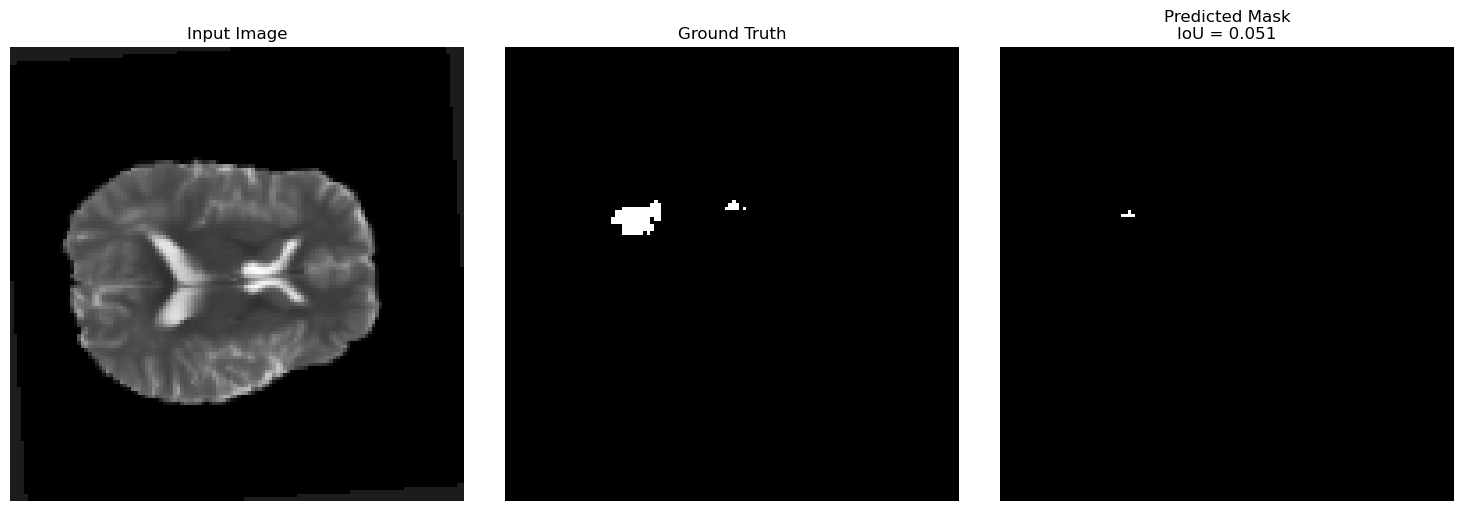

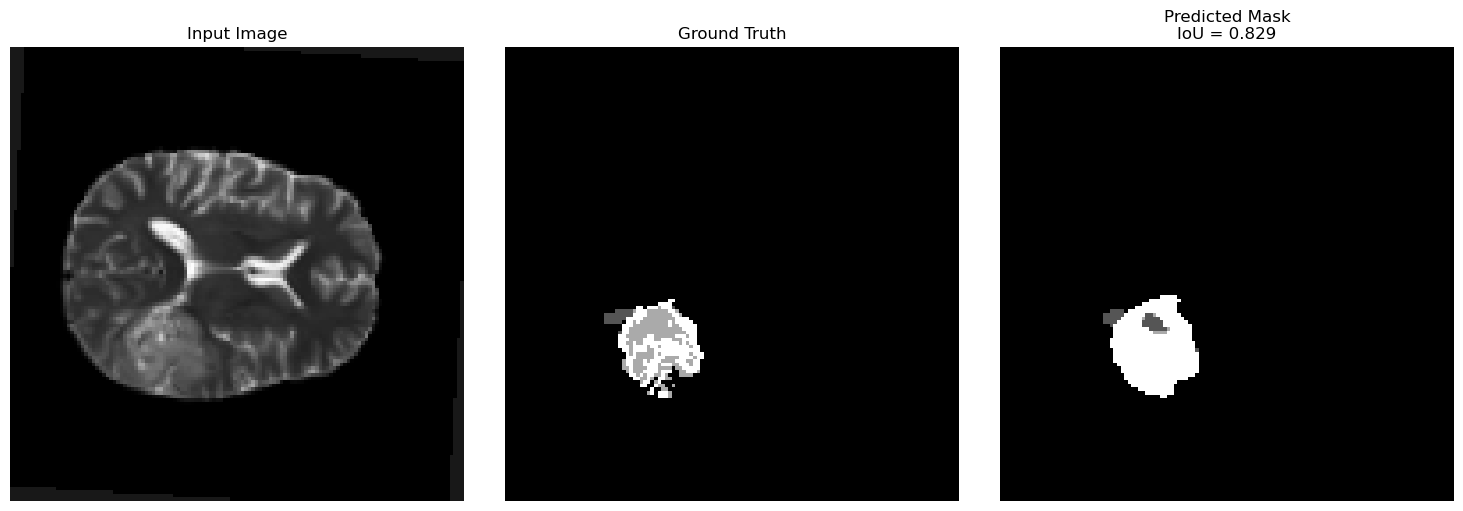

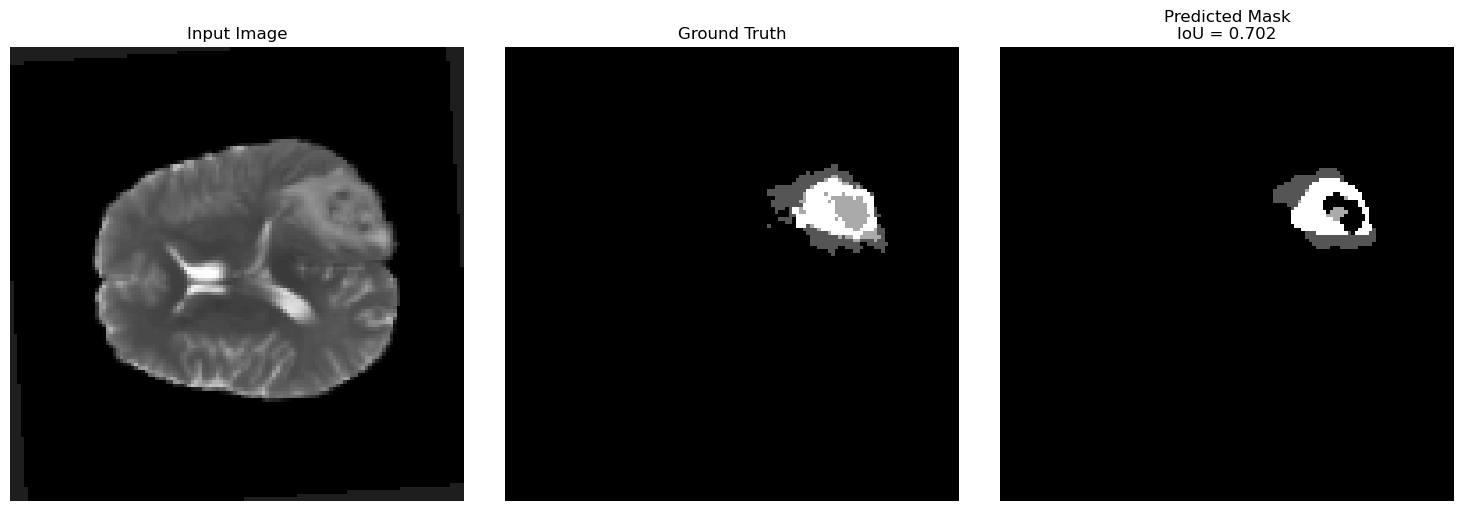

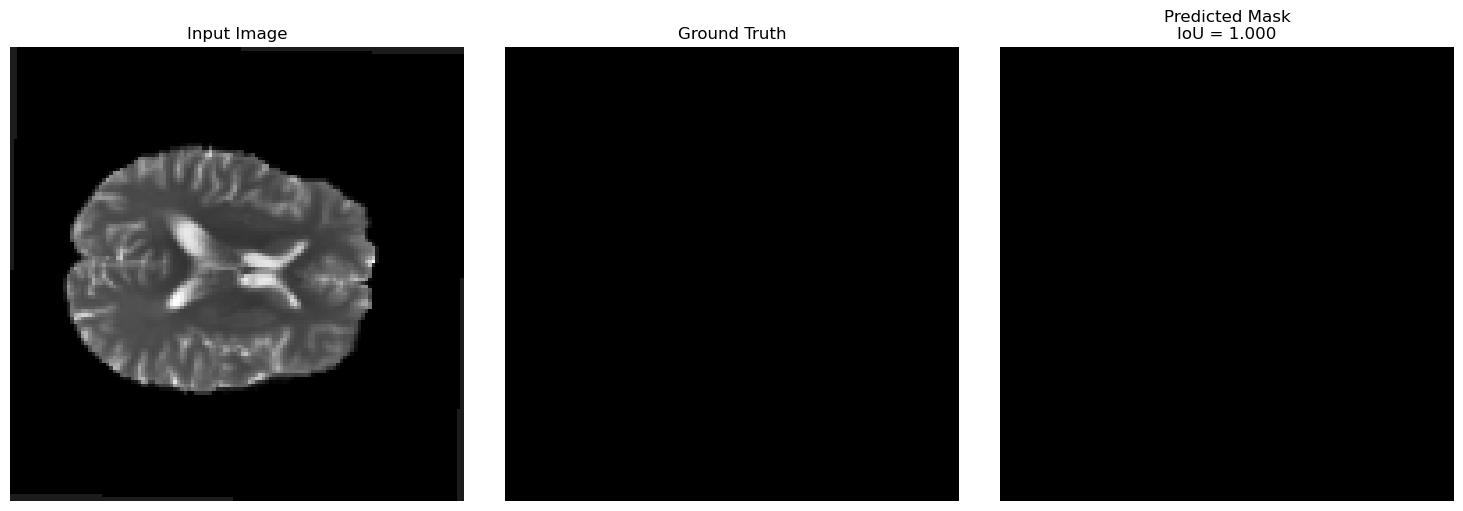

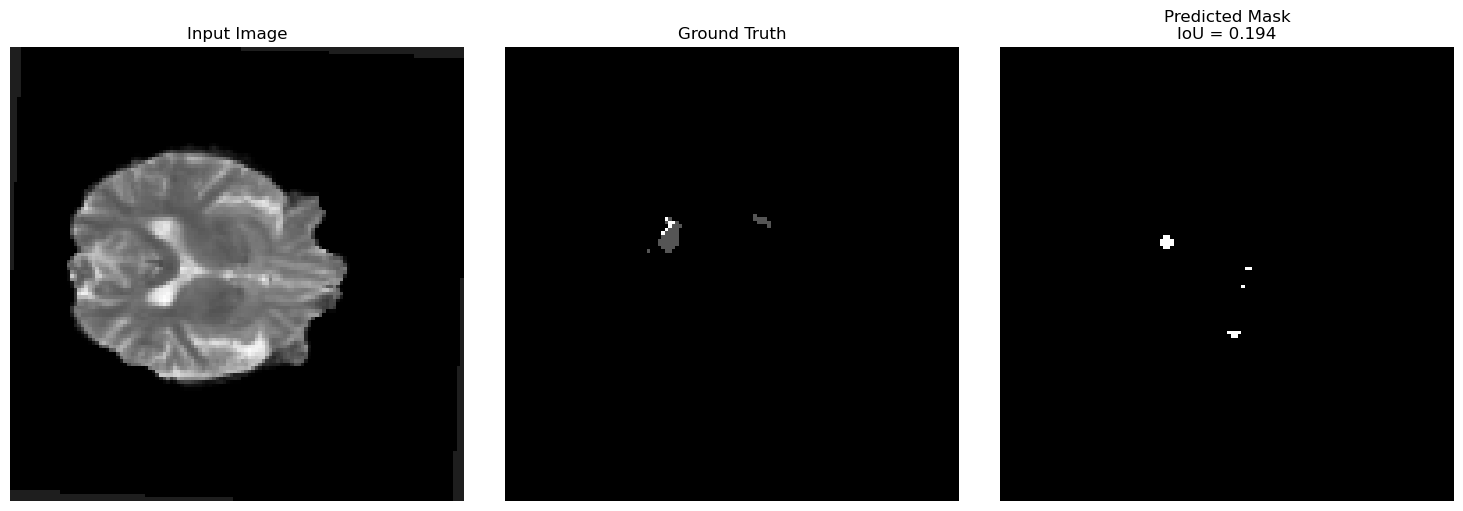


Evaluation for Fold 2 / 5


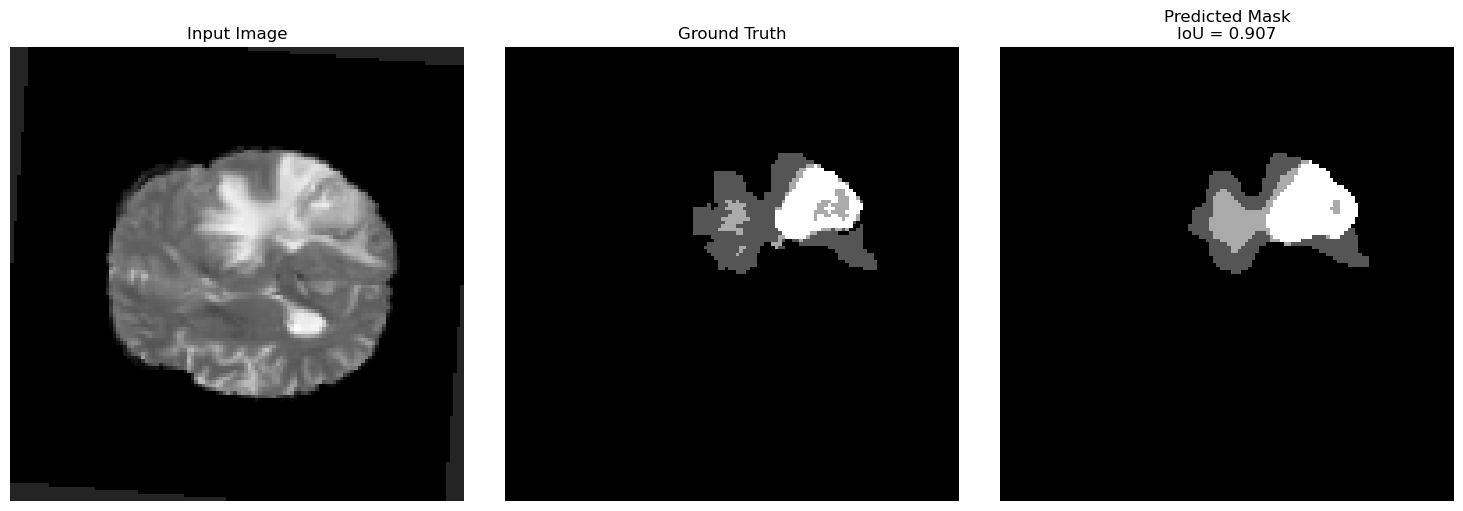

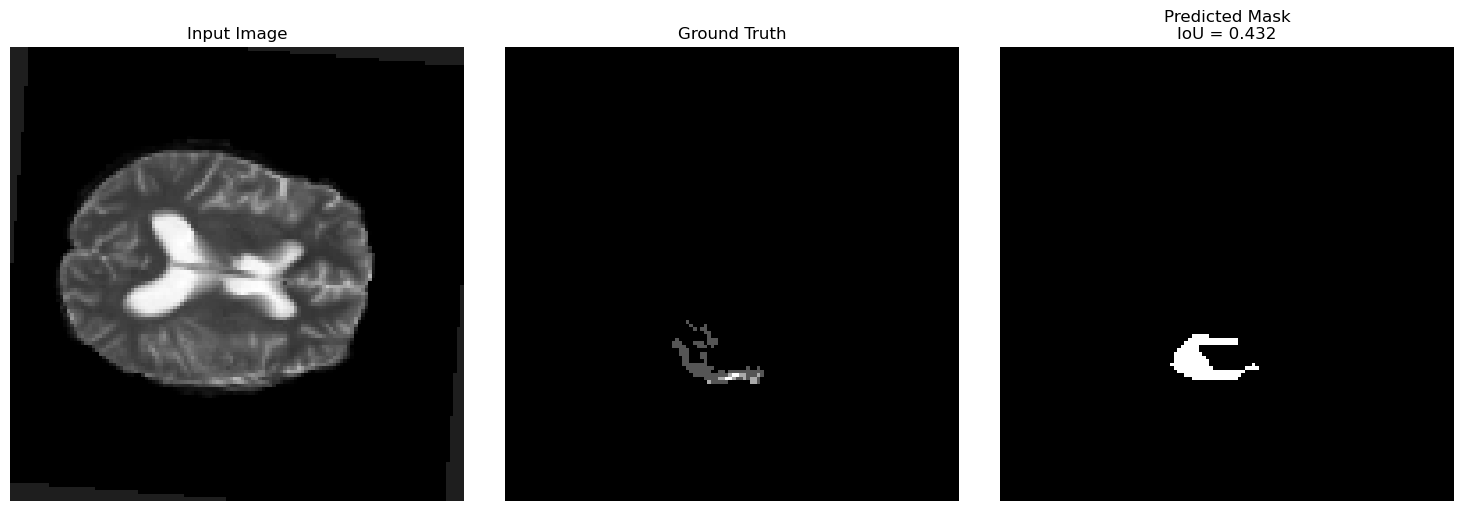

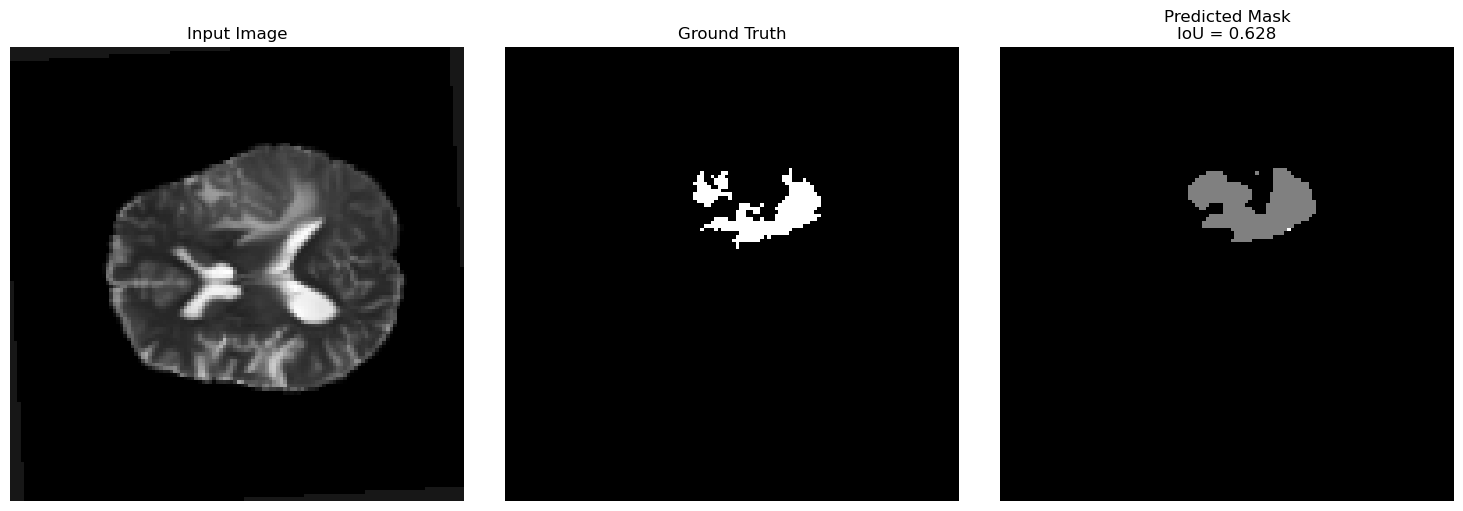

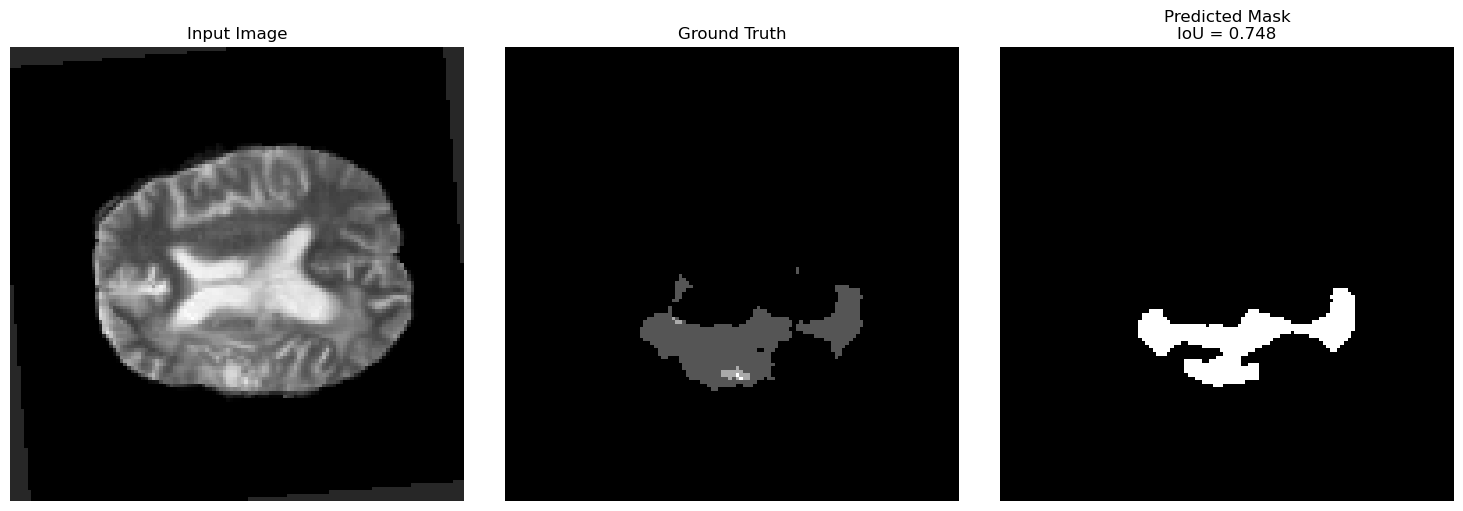

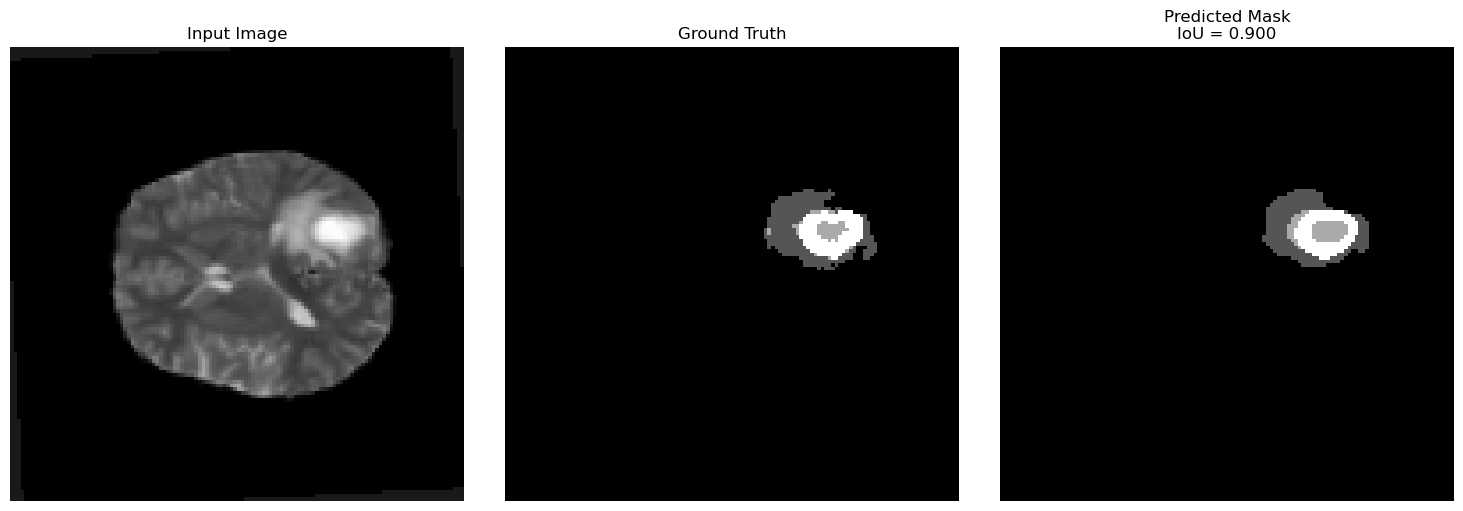


Evaluation for Fold 3 / 5


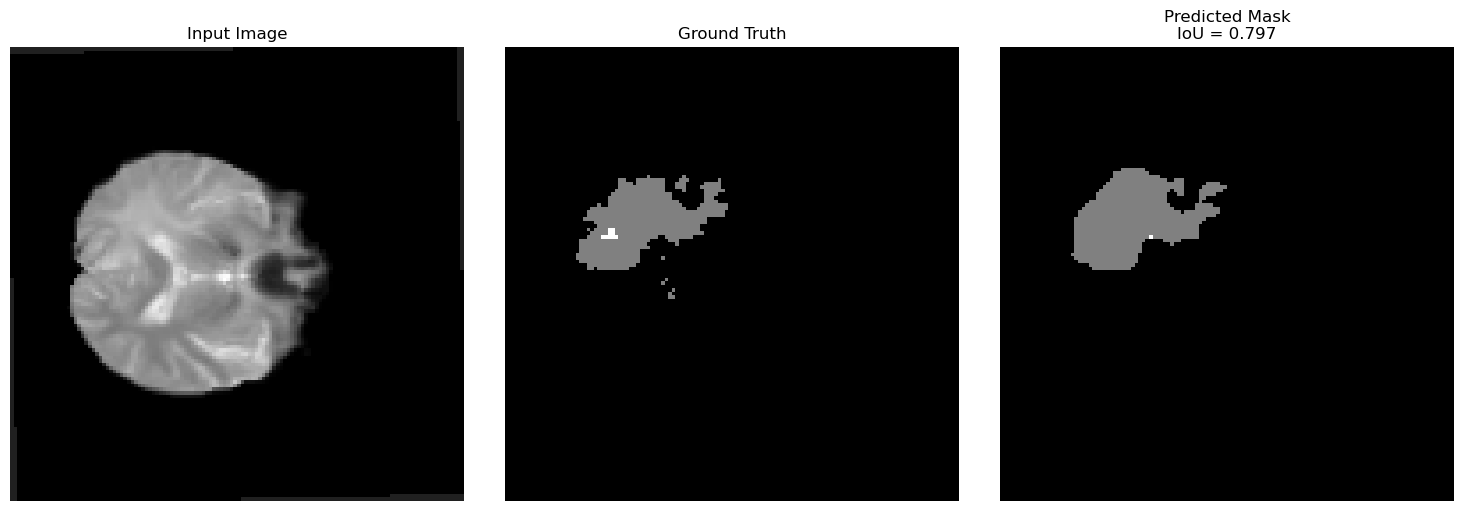

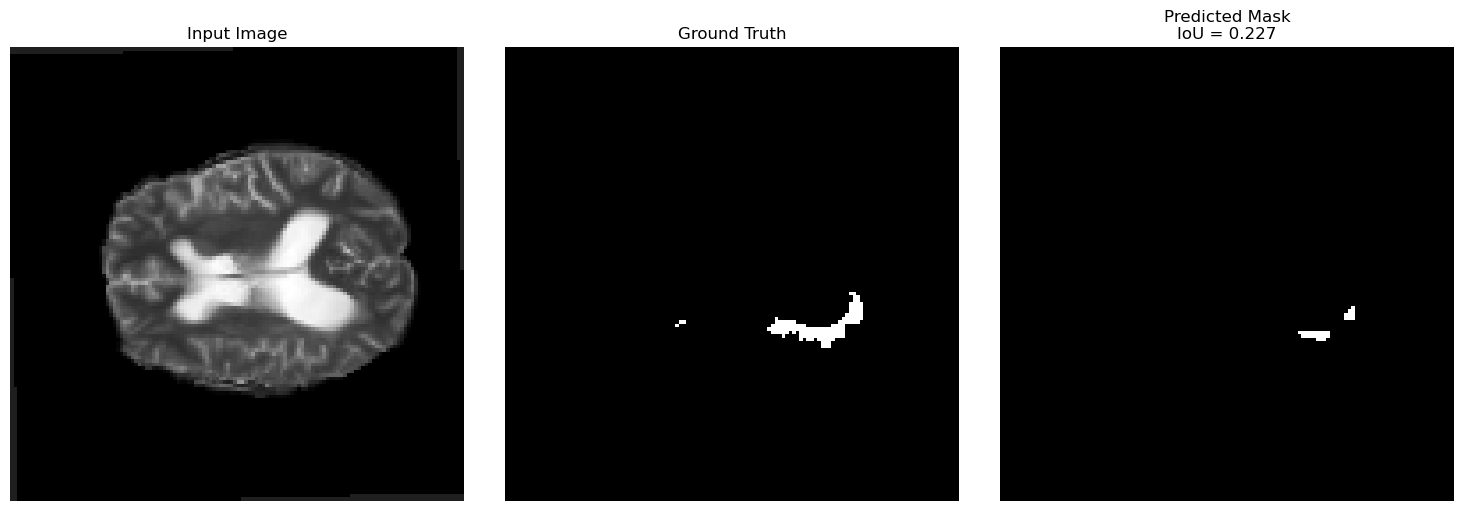

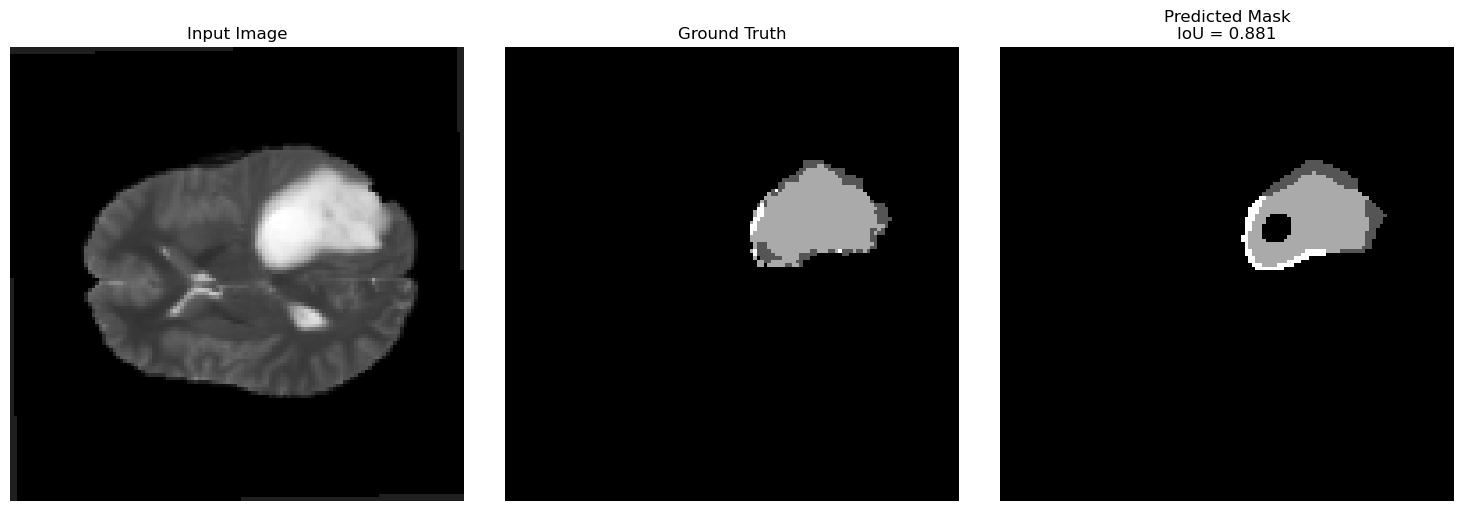

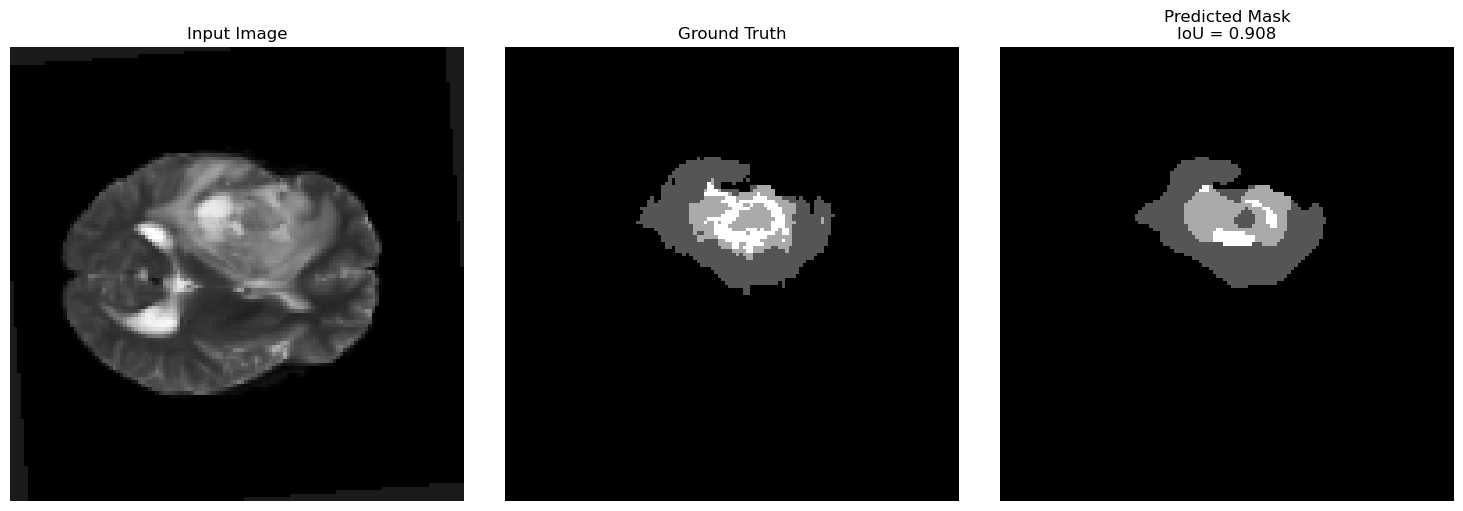

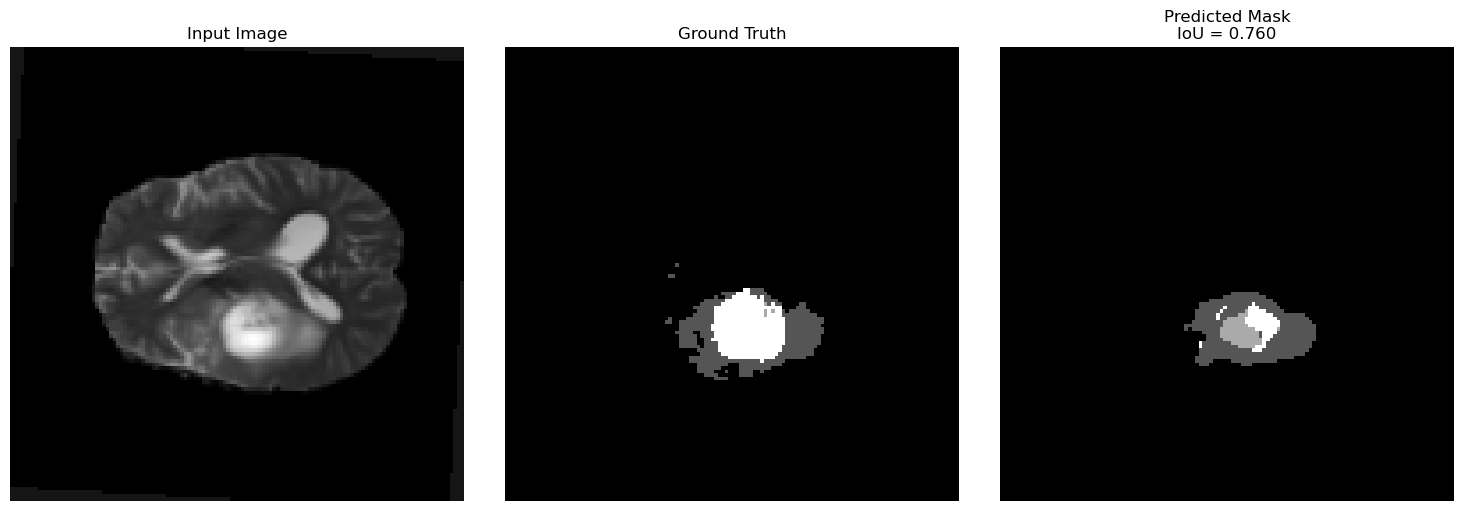


Evaluation for Fold 4 / 5


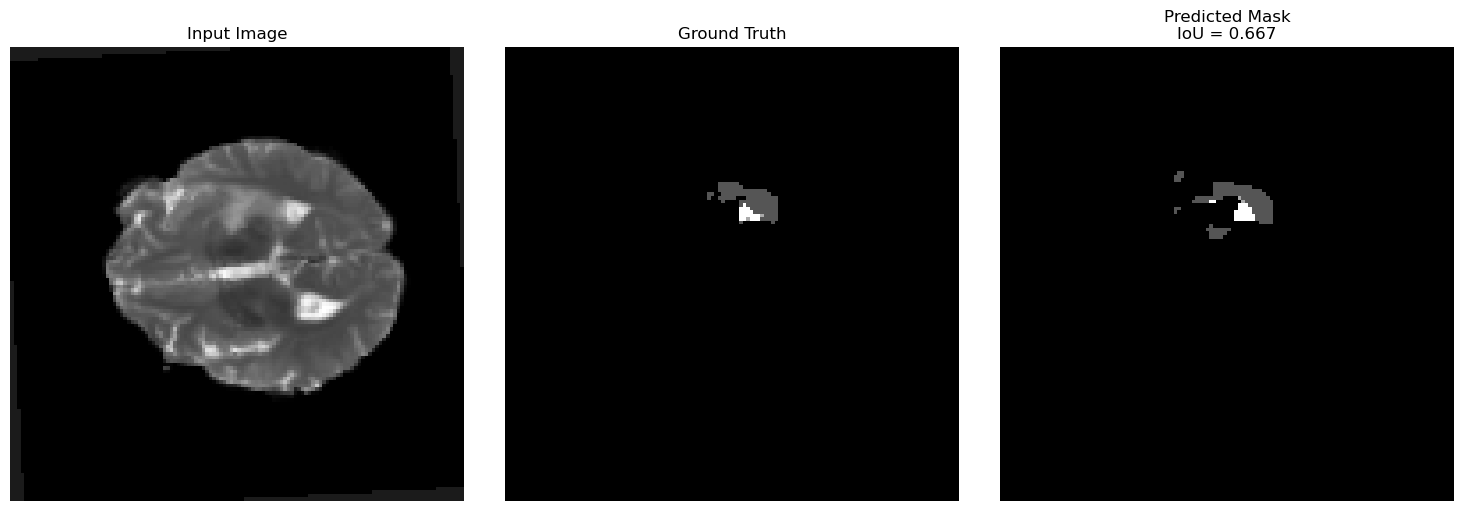

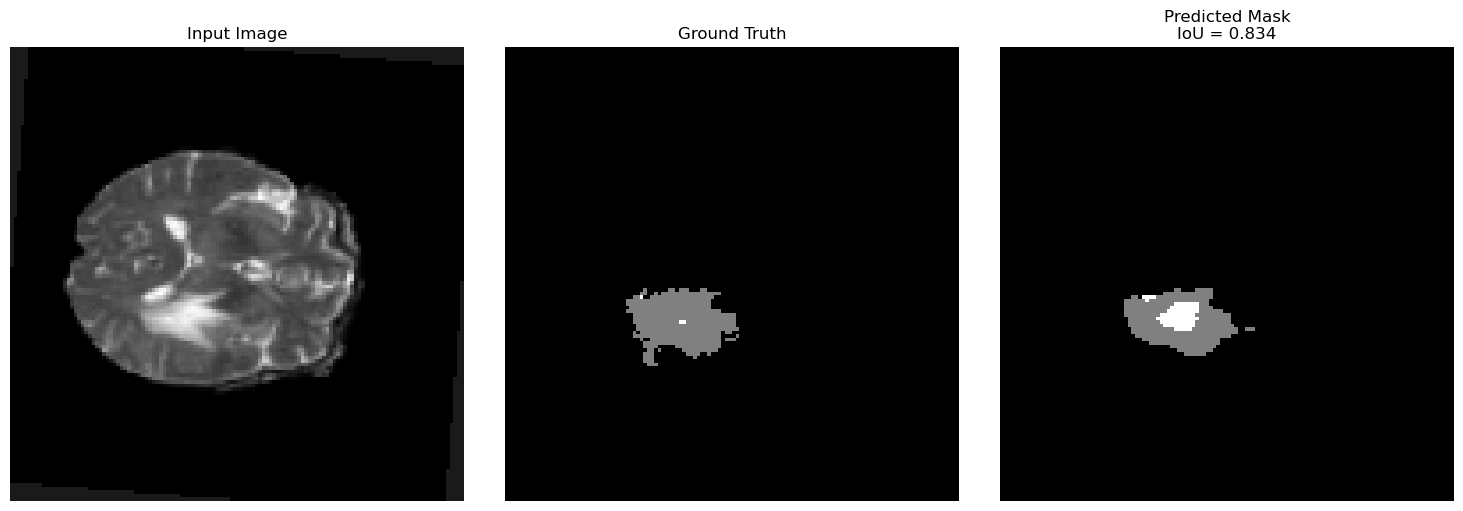

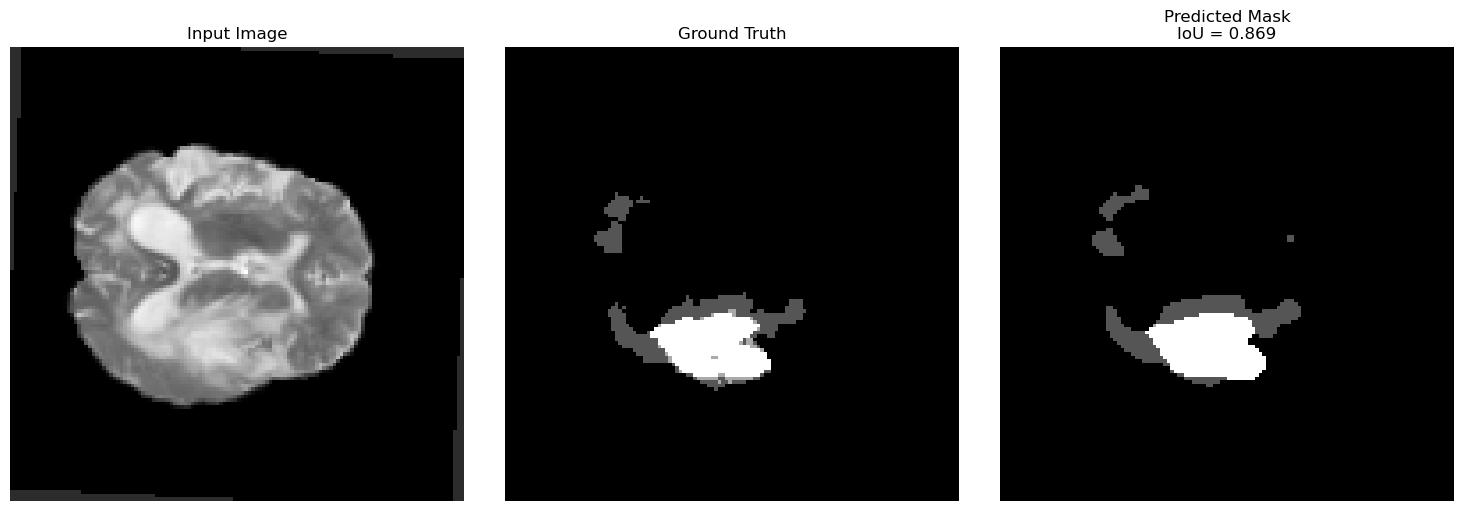

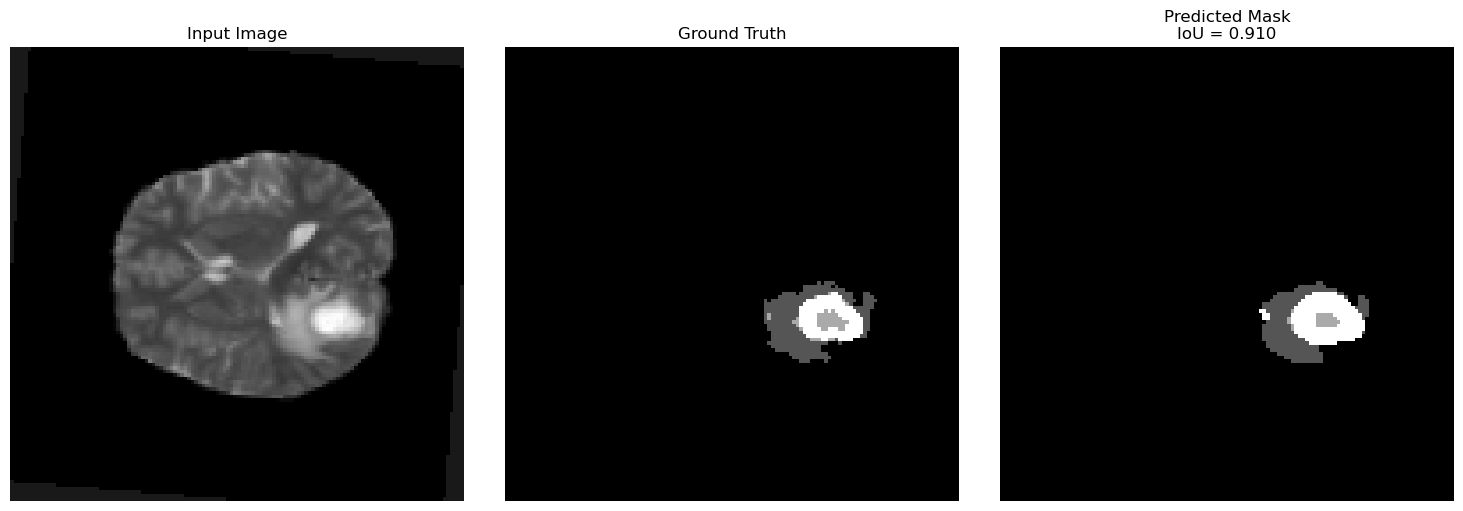

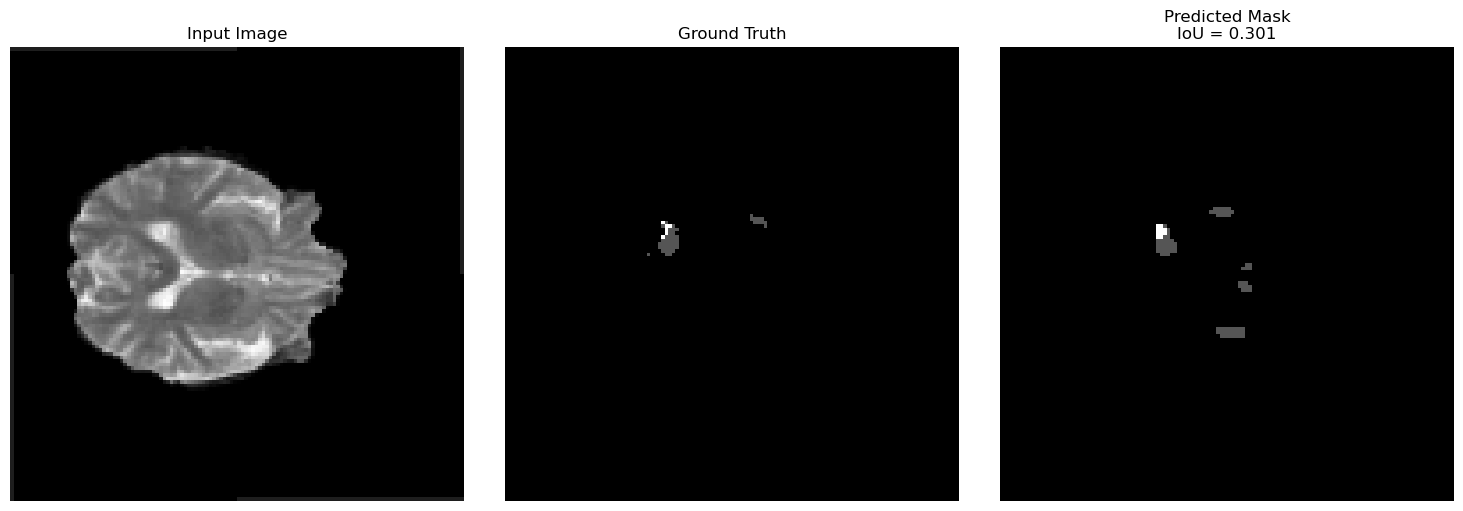


Evaluation for Fold 5 / 5


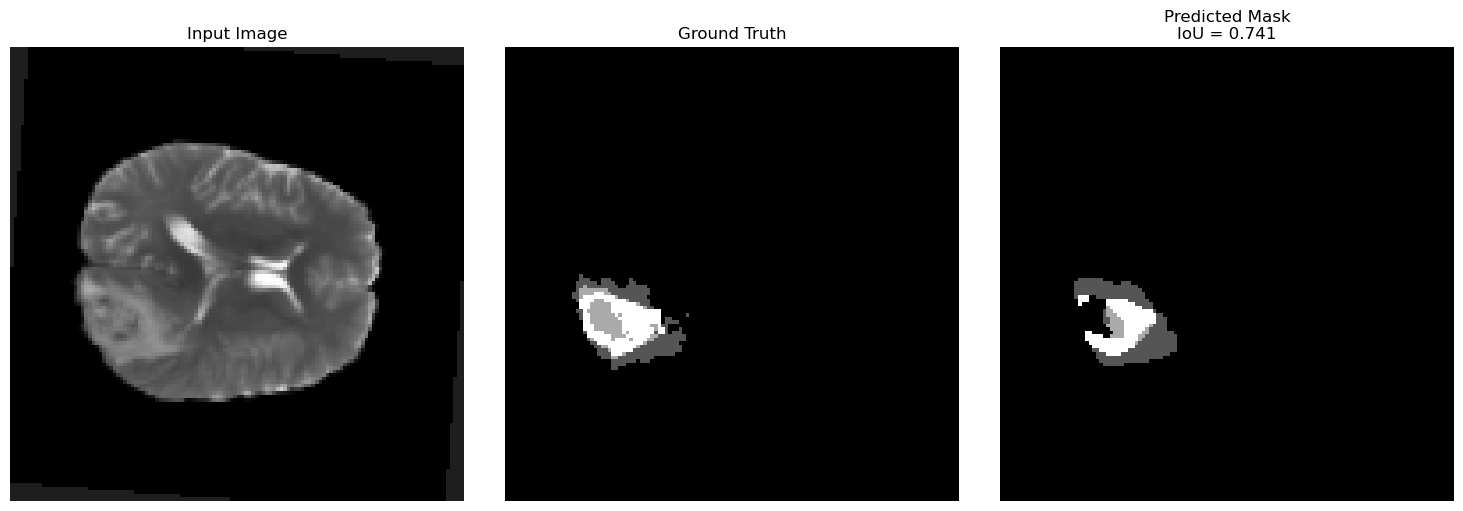

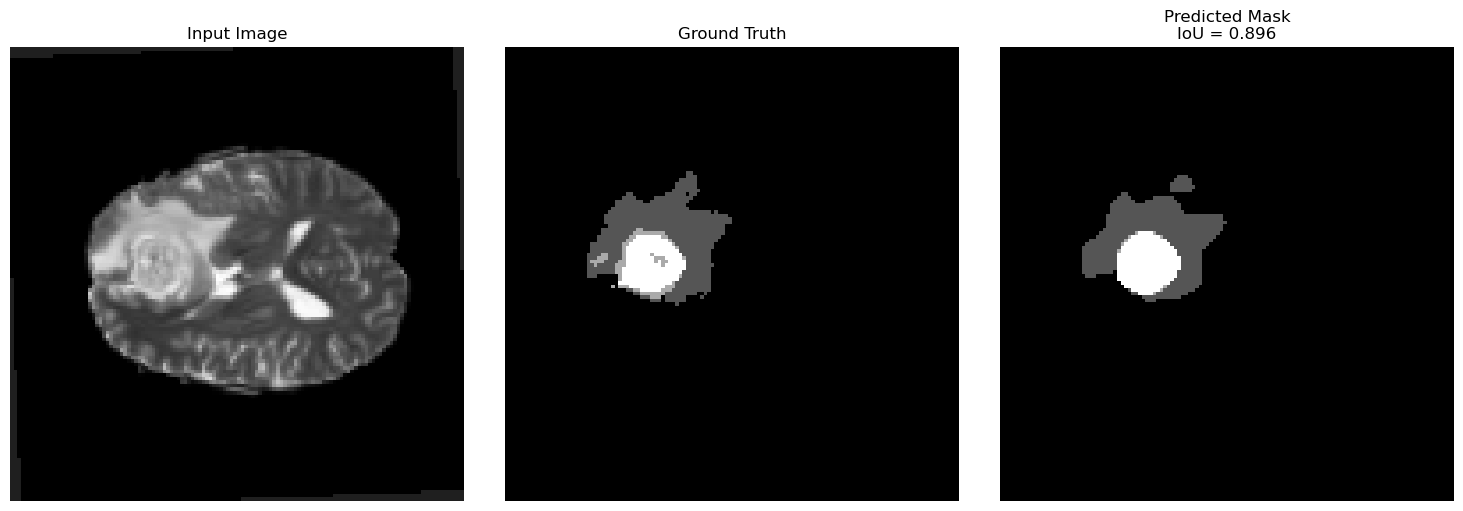

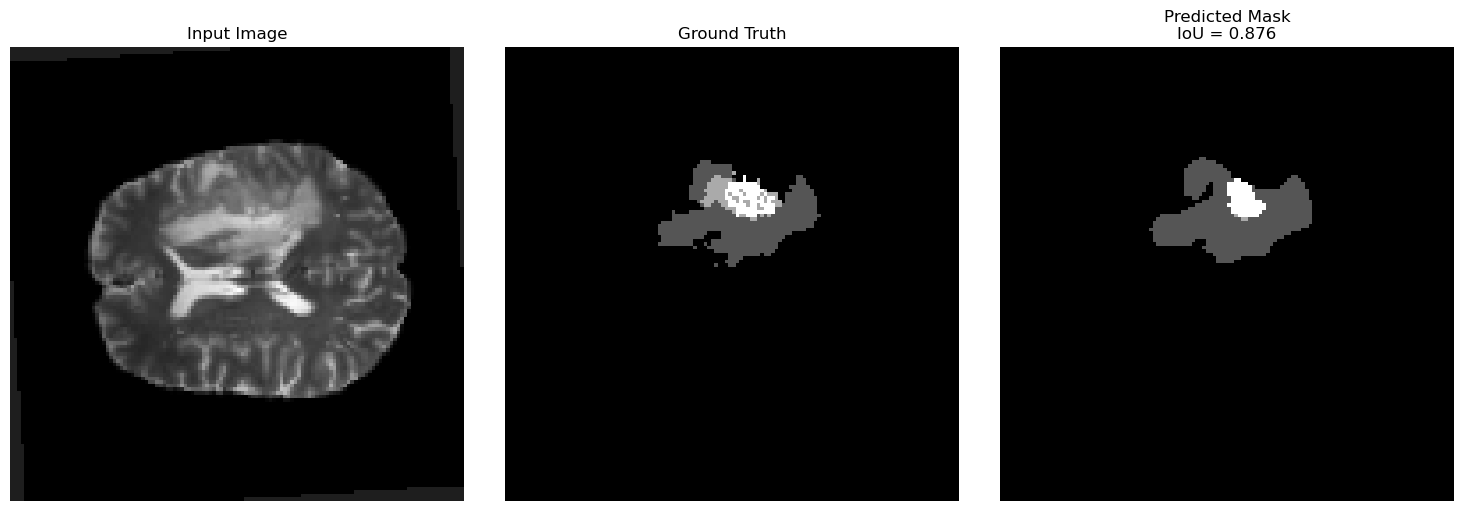

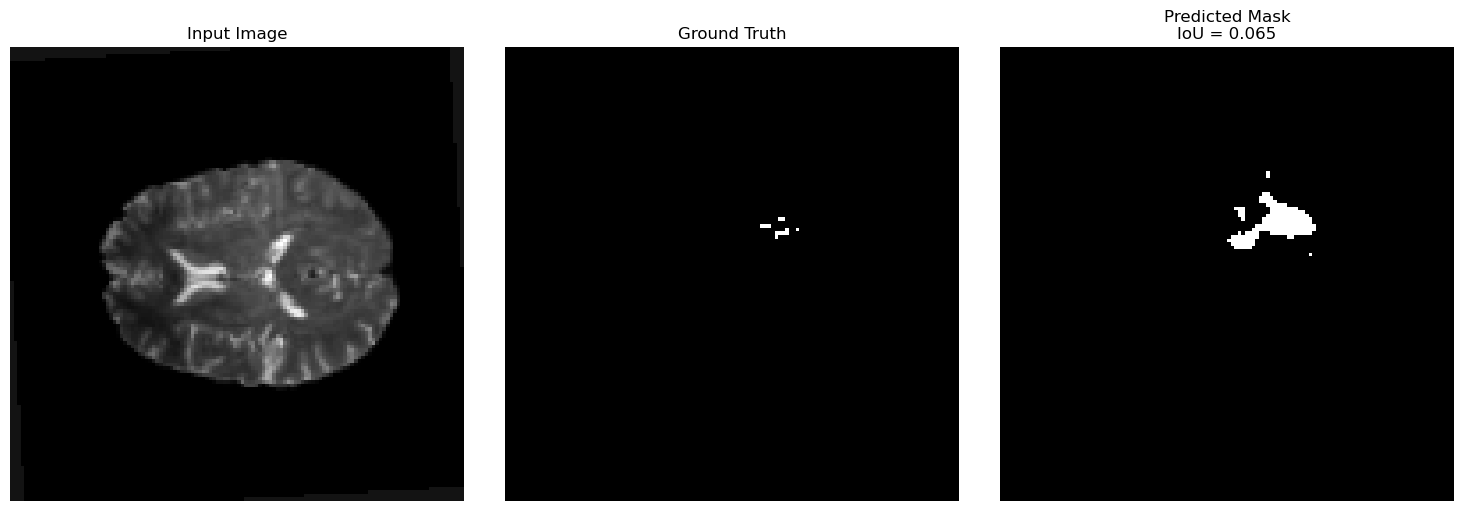

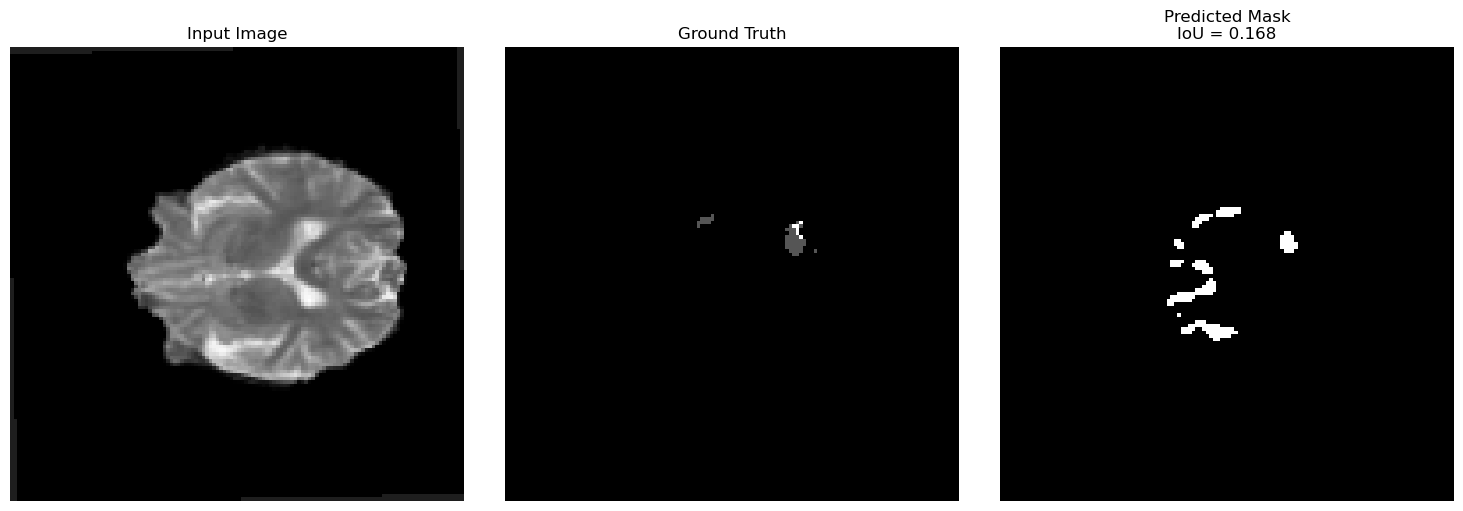

In [ ]:
if __name__ == "__main__":

    model = UNet(in_channels=4, out_channels=4, base_filters=64).to(device)

    for fold_idx in range(num_splits):
        print("\n"+"="*40)
        print(f"Evaluation for Fold {fold_idx+1} / {num_splits}")
        print("="*40)
        
        checkpoint_path = f"checkpoints_brain_tumor/fold_{fold_idx + 1}/unet_epoch30.pth"
        
        state_dict = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(state_dict)
        
        evaluate(model,val_datasets[fold_idx], device, max_examples=5)